# Extended NeRF: view-dependent colour + hierarchical sampling
**Group 4**: Karan Rooprai (n12498122), Nhu Hieu Nguyen (n12194778)

The assessment starter code completed. **Task 1** makes colour depend on the viewing direction while density stays a function of position only. **Task 2** renders each ray in two passes: a coarse network on uniform samples finds where the geometry is, and a fine network evaluates extra samples drawn there. The pipeline (data, rays, encoding, volume rendering, training loop) is the tutorial's.

In [1]:
# PyTorch NeRF Implementation (same stack as Tutorial 10.4)
import os
import json
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm
from IPython.display import clear_output

# Set device. Every tensor and network below is moved to it with .to(device).
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device} | torch {torch.__version__}")

# Reproducibility: one seed for weights, ray shuffling and the stratified jitter.
SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Scene bounds and sample budgets shared by every model in this project.
NEAR, FAR = 2.0, 6.0          # ray segment that contains the object (tutorial values)
N_SAMPLES_TINY = 64           # Tiny NeRF: uniform samples per ray (tutorial value)
N_C, N_F = 32, 64             # Extended NeRF: coarse samples, extra fine samples (starter values)

Using device: cuda | torch 2.13.0+cu126


# Data - Batching Rays
The synthetic scene `tiny_nerf_data.npz` holds 106 posed 100x100 RGB images of a Lego
bulldozer and the camera's focal length. Each pose is a 4x4 camera-to-world matrix: its first
three columns turn camera axes into world axes and its last column is the camera centre. As in
the starter code, views 0-99 train the model and views 100-105 are held out for testing, so every
reported metric comes from cameras the model never saw.

In [2]:
data = np.load('tiny_nerf_data.npz')
images = torch.from_numpy(data['images']).float().to(device)
poses = torch.from_numpy(data['poses']).float().to(device)
focal = float(data['focal'])
H, W = images.shape[1:3]
K = torch.Tensor([[focal, 0, W/2.0], [0, focal, H/2.0], [0, 0, 1]]).float().to(device)
print(f"dataset: Images shape={images.shape}, Poses shape={poses.shape}, Intrinsics={K.shape}")

# Splitting the dataset into training and test sets exactly as the starter code does:
# the last 6 views are never seen during training and are used for every reported metric.
test_images, test_poses = images[100:], poses[100:]
train_images, train_poses = images[:100], poses[:100]
print(f"training split: {train_images.shape}, training pose shape: {train_poses.shape}")
print(f"test split: {test_images.shape}, test pose shape: {test_poses.shape}")

dataset: Images shape=torch.Size([106, 100, 100, 3]), Poses shape=torch.Size([106, 4, 4]), Intrinsics=torch.Size([3, 3])
training split: torch.Size([100, 100, 100, 3]), training pose shape: torch.Size([100, 4, 4])
test split: torch.Size([6, 100, 100, 3]), test pose shape: torch.Size([6, 4, 4])


The six training views on top and the six held-out test views underneath, to show what the model
has to reproduce: the cameras circle the object at different heights.

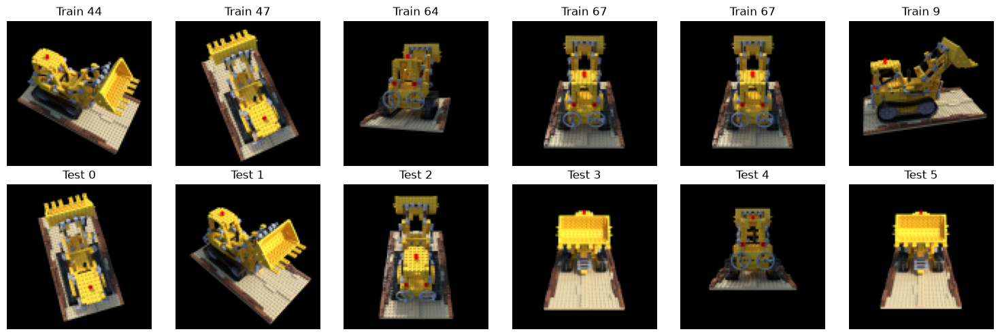

In [3]:
# Six training views (top) and the six held-out test views (bottom).
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for i, sample_idx in enumerate(np.random.randint(0, train_images.shape[0], 6)):
    axes[0, i].imshow(train_images[sample_idx].cpu().numpy())
    axes[0, i].set_title(f'Train {sample_idx}')
    axes[0, i].axis('off')
for i in range(6):
    axes[1, i].imshow(test_images[i].cpu().numpy())
    axes[1, i].set_title(f'Test {i}')
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

Each pixel defines a ray $\mathbf{r}(t) = \mathbf{o} + t\mathbf{d}$ from the camera centre
$\mathbf{o}$ through the pixel. `get_rays` builds the direction in camera coordinates from the
pinhole model, $((i - c_x)/f,\; -(j - c_y)/f,\; -1)$ (the camera looks down its own $-z$ axis
and image rows grow downwards), then rotates it into world coordinates with the pose.

In [4]:
def get_rays(K, c2w, H, W):
    """
    Get the origin and direction of the ray through every pixel of a camera with
    intrinsics K and camera-to-world pose c2w (Tutorial 10.4, unchanged).
    """
    # 1. Create pixel grid, x first
    i, j = torch.meshgrid(
        torch.arange(W, dtype=torch.float32, device=c2w.device),
        torch.arange(H, dtype=torch.float32, device=c2w.device),
        indexing='xy'
    )

    # 2. Get directions in camera coordinates: (u - cx)/fx, (v - cy)/fy, with the camera
    #    looking down -z and the y-axis flipped (standard NeRF orientation)
    dirs = torch.stack([
        (i - K[0, 2]) / K[0, 0],
        -(j - K[1, 2]) / K[1, 1],
        -torch.ones_like(i)
    ], dim=-1)

    # 3. Transform directions to world space: (H, W, 3) @ (3, 3) -> (H, W, 3)
    rays_d = dirs @ c2w[:3, :3].T

    # 4. Origin is the translation vector of the camera-to-world matrix
    rays_o = c2w[:3, -1].expand(rays_d.shape)
    return rays_o, rays_d

All 100 x 100 x 100 = 1,000,000 training rays are pooled and served in shuffled batches of 1,024,
so one gradient step mixes pixels from many cameras rather than one image at a time.

In [5]:
class NeRFDataset(torch.utils.data.Dataset):
    """Pool of all training rays (Tutorial 10.4, unchanged)."""
    def __init__(self, images, poses, intrinsic):
        """
        images: (N_images, H, W, 3)
        poses: (N_images, 4, 4)
        """
        self.images, self.poses, self.intrinsic = images, poses, intrinsic
        self.H, self.W = images.shape[1], images.shape[2]
        self.all_rays_o, self.all_rays_d, self.all_rays_rgbs = [], [], []

        # compute all rays
        for i in range(len(images)):
            rays_o, rays_d = get_rays(self.intrinsic, self.poses[i], self.H, self.W)
            self.all_rays_o.append(rays_o.reshape(-1, 3))
            self.all_rays_d.append(rays_d.reshape(-1, 3))
            self.all_rays_rgbs.append(images[i].reshape(-1, 3))

        # Concatenate all rays from all images
        self.all_rays_o = torch.cat(self.all_rays_o, dim=0)
        self.all_rays_d = torch.cat(self.all_rays_d, dim=0)
        self.all_rays_rgbs = torch.cat(self.all_rays_rgbs, dim=0)

    def __len__(self):
        return len(self.all_rays_o)

    def __getitem__(self, idx):
        return (self.all_rays_o[idx], self.all_rays_d[idx], self.all_rays_rgbs[idx])


def make_train_dataloader(seed=SEED, batch_size=1024):
    """
    Same dataset, batch size (1024 rays) and shuffling as the tutorial. The only change is
    how a batch is fetched: a BatchSampler hands __getitem__ a whole list of indices, so a
    batch is one tensor gather on the GPU instead of 1,024 Python calls plus a collate. The
    batches are identical in content; an epoch simply runs several times faster.
    """
    dataset = NeRFDataset(train_images, train_poses, K)
    generator = torch.Generator().manual_seed(seed)
    batch_sampler = torch.utils.data.BatchSampler(
        torch.utils.data.RandomSampler(dataset, generator=generator), batch_size, drop_last=False)
    return torch.utils.data.DataLoader(dataset, sampler=batch_sampler, batch_size=None)

# Model - Neural Scene Representation
**Positional encoding.** A small MLP fed raw coordinates learns only smooth functions, so sharp
edges and fine texture come out blurred. Lifting each coordinate to
$\gamma(p) = (p, \sin(2^0\pi p), \cos(2^0\pi p), \dots, \sin(2^{L-1}\pi p), \cos(2^{L-1}\pi p))$
gives the network inputs that already vary quickly, so detail costs it far less. With $L = 6$ a 3D
point becomes $3 + 3 \cdot 2 \cdot 6 = 39$ numbers.

In [6]:
class PositionalEncoding(torch.nn.Module):
    """
    Positional encoding gamma(p) = [p, sin(2^k pi p), cos(2^k pi p)], k = 0..L-1 (Tutorial 10.4).
    Maps (N, D) -> (N, D + 2*L*D).
    """
    def __init__(self, L_embed=6):
        super(PositionalEncoding, self).__init__()
        self.L_embed = L_embed
        self.bands = (2.0 ** torch.arange(L_embed, dtype=torch.float32).to(device)) * torch.pi
        self.bands = self.bands.view(1, L_embed, 1)  # shape (1, L_embed, 1)

    def forward(self, x):
        x_scaled = x.unsqueeze(-2) * self.bands                                  # (N, L, D)
        sin_cos = torch.cat([torch.sin(x_scaled), torch.cos(x_scaled)], dim=-2)  # (N, 2L, D)
        sin_cos = sin_cos.flatten(start_dim=-2)                                  # (N, 2LD)
        return torch.cat([x, sin_cos], dim=-1)                                   # (N, D + 2LD)

## Task 1: view-dependent radiance field
Tiny NeRF gives each 3D point one colour, so it cannot show anything that changes with the camera,
such as a highlight that slides across a glossy surface. The upgraded network is
$F_\theta: (\gamma(\mathbf{x}), \gamma(\mathbf{d})) \mapsto (\sigma, \mathbf{c})$, wired so
that **only the colour can depend on the viewing direction** $\mathbf{d}$:

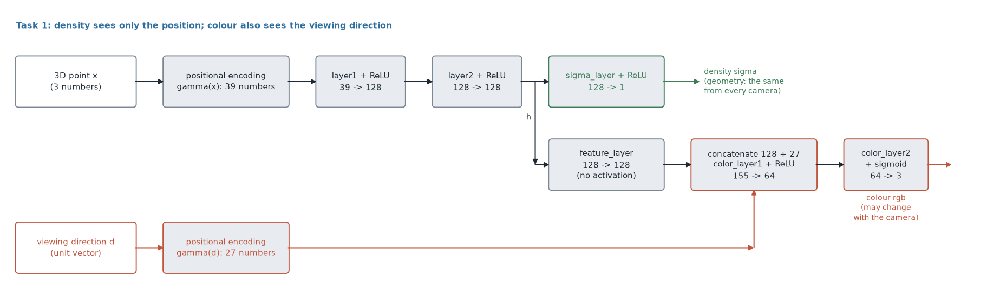

* The density $\sigma$ is read from the position trunk **before** the direction enters, so the
  geometry is the same from every camera. If density could see the direction, the network could
  explain each photograph with a different shape and still fit it, and the scene would no longer
  be one consistent 3D object.
* `feature_layer` passes 128 position features to the colour head with no activation, as in the
  original NeRF, and the colour head concatenates them with $\gamma(\mathbf{d})$.
* The direction uses $L_{dir} = 4$ frequencies (27 numbers) against $L = 6$ for position, because
  colour changes slowly with the viewing angle compared with how fast it changes across the surface.
* `view_dependent=False` replaces the direction by zeros. It exists only for ablation A below: the
  same network, the same size, but matte again.

In [7]:
class NeRF(torch.nn.Module):
    r"""
    TASK 1. NeRF MLP with view-direction dependency (layers exactly as in the starter code).
    Density depends on position only; colour depends on position features + view direction.

        gamma(x) -> layer1 -> layer2 -> h --> sigma_layer --> sigma        (geometry)
                                          \-> feature_layer --+
                                gamma(d) ---------------------+-> color_layer1 -> color_layer2 -> rgb

    Because sigma is computed before the direction enters, the geometry is the same from every
    camera (multi-view consistency); only the colour can change with the angle, which is what
    lets the model reproduce specular highlights and reflections.

    view_dependent=False is used only by the ablation study: the direction input is replaced by
    zeros, so the network keeps exactly the same size but becomes a matte renderer again.
    """
    def __init__(self, filter_size=128, L_embed=6, L_dir=4, view_dependent=True):
        super(NeRF, self).__init__()
        self.view_dependent = view_dependent
        self.positional_encoding = PositionalEncoding(L_embed)
        self.direction_encoding = PositionalEncoding(L_dir)

        x_dim = 3 + 3 * 2 * L_embed   # 39 for L_embed = 6
        d_dim = 3 + 3 * 2 * L_dir     # 27 for L_dir = 4

        # Position trunk
        self.layer1 = torch.nn.Linear(x_dim, filter_size)
        self.layer2 = torch.nn.Linear(filter_size, filter_size)

        # Density
        self.sigma_layer = torch.nn.Linear(filter_size, 1)
        # geometric features passed on to the colour head
        self.feature_layer = torch.nn.Linear(filter_size, filter_size)

        # Color head conditioned on view direction
        self.color_layer1 = torch.nn.Linear(filter_size + d_dim, filter_size // 2)
        self.color_layer2 = torch.nn.Linear(filter_size // 2, 3)

    def forward(self, x, dir):
        # Position trunk on the encoded 3D point
        h = F.relu(self.layer1(self.positional_encoding(x)))
        h = F.relu(self.layer2(h))

        # Density from position only (ReLU keeps it non-negative)
        sigma = F.relu(self.sigma_layer(h))

        # Colour from the geometric features and the encoded unit viewing direction.
        # As in the original NeRF, the feature vector has no activation before the concat.
        if not self.view_dependent:
            dir = torch.zeros_like(dir)
        features = self.feature_layer(h)
        c = F.relu(self.color_layer1(torch.cat([features, self.direction_encoding(dir)], dim=-1)))
        rgb = torch.sigmoid(self.color_layer2(c))
        return torch.cat([sigma, rgb], dim=-1)

# Inference - Volume Rendering
A pixel's colour is the colour of the ray's samples, each weighted by how much light it sends to
the camera:
$C(\mathbf{r}) \approx \sum_i w_i \mathbf{c}_i$ with $w_i = T_i\alpha_i$,
$\alpha_i = 1 - e^{-\sigma_i\delta_i}$ (the chance the ray stops in sample $i$'s interval of
length $\delta_i$) and $T_i = \prod_{j<i}(1-\alpha_j)$ (the chance it got that far). The weights
$w_i$ therefore show where along the ray the visible surface is, which Task 2 uses.

In [8]:
def volume_rendering(sigma, rgb, t_vals):
    """
    Discrete volume rendering (Tutorial 10.4, unchanged).
    sigma: [N_rays, N_samples], rgb: [N_rays, N_samples, 3], t_vals: [N_rays, N_samples].
    Returns the pixel colours [N_rays, 3] and the per-sample weights w_i = T_i * alpha_i.
    """
    # Distance between adjacent samples, with a very large last interval
    deltas = t_vals[..., 1:] - t_vals[..., :-1]
    last_dist = torch.full_like(deltas[..., :1], 1e10)
    deltas = torch.cat([deltas, last_dist], dim=-1)

    # alpha_i = 1 - exp(-sigma_i * delta_i)  (sigma >= 0 is ensured by the ReLU in the MLP)
    alpha = 1.0 - torch.exp(-sigma * deltas)

    # Transmittance T_i = prod_{j<i} (1 - alpha_j), with T_1 = 1
    shifted_transmittance = torch.cat([torch.ones_like(alpha[..., :1]), 1.0 - alpha + 1e-10], dim=-1)
    T = torch.cumprod(shifted_transmittance, dim=-1)[..., :-1]

    # colour blending
    weights = alpha * T
    rgb_map = torch.sum(weights[..., None] * rgb, dim=-2)
    return rgb_map, weights

## Task 2: hierarchical sampling with coarse and fine networks
With 64 evenly spaced samples most of the network's work lands in empty air in front of or behind
the object. Hierarchical sampling spends the samples where the surface is:

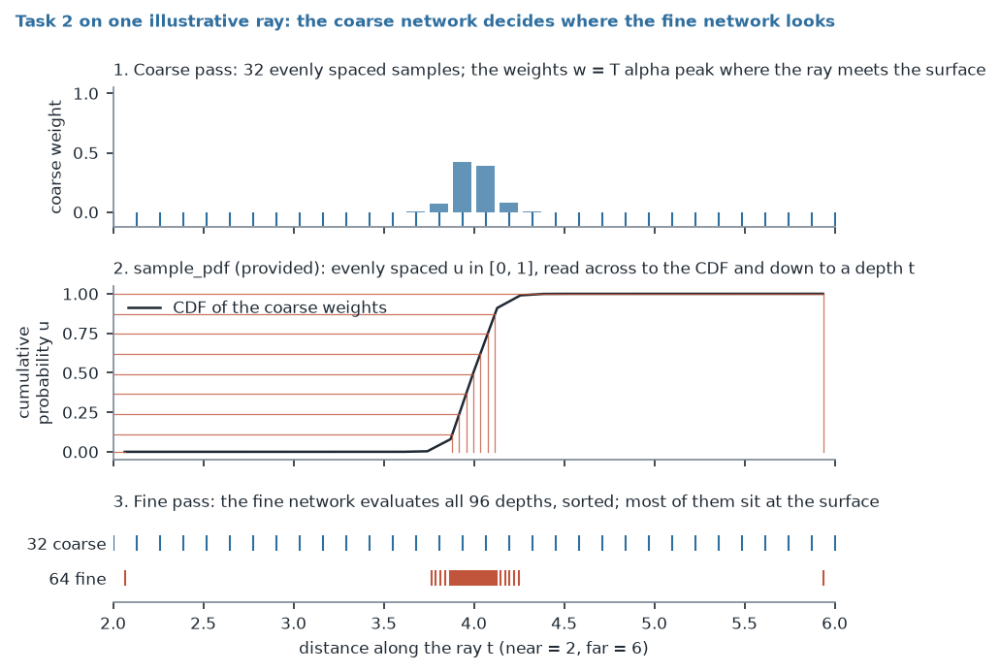

1. **Coarse pass**: $N_c = 32$ stratified samples, evaluated by the coarse network. Their weights
   $w_i = T_i\alpha_i$ show where the surface is likely to be.
2. **Fine pass**: the coarse weights between neighbouring samples become a probability
   distribution along the ray. `sample_pdf` (provided by the starter, unchanged) draws $N_f = 64$
   depths from it by inverse-transform sampling: a value $u$ in $[0, 1]$ is read across to the
   cumulative distribution and down to the depth where it is reached. The fine network then
   evaluates all $N_c + N_f = 96$ depths, sorted, so the coarse samples still cover the whole ray.
3. **Both passes are supervised**,
   $\mathcal{L} = \lVert C^c - I\rVert^2 + \lVert C^f - I\rVert^2$: without the coarse term the
   coarse network would get no gradient (the sampling is detached) and would never learn where the
   surface is.

The two end weights are dropped because the PDF needs one value per bin between neighbouring
samples ($N_c - 1$ bins, $N_c - 2$ interior weights). In the deterministic branch the draws include
$u = 0$ and $u = 1$, which land at the two ends of the ray, as the figure shows.

In [9]:
def sample_pdf(bins, weights, N_samples, rand=False):
    """Inverse-transform sampling along each ray (provided by the starter code, unchanged)."""
    # Get PDF and CDF from weights
    weights = weights + 1e-5  # Prevent division by zero
    pdf = weights / torch.sum(weights, dim=-1, keepdim=True)
    cdf = torch.cumsum(pdf, dim=-1)
    cdf = torch.cat([torch.zeros_like(cdf[..., :1]), cdf], dim=-1)  # [N_rays, N_bins + 1]

    # Sample uniform points u
    if rand:
        u = torch.rand(list(cdf.shape[:-1]) + [N_samples], device=cdf.device)
    else:
        u = torch.linspace(0., 1., steps=N_samples, device=cdf.device)
        u = u.expand(list(cdf.shape[:-1]) + [N_samples])
    u = u.contiguous()

    # Find indices where u fits in the CDF
    inds = torch.searchsorted(cdf, u, right=True)
    below = torch.max(torch.zeros_like(inds - 1), inds - 1)
    above = torch.min((cdf.shape[-1] - 1) * torch.ones_like(inds), inds)

    # Gather CDF values for the intervals
    cdf_g0 = torch.gather(cdf, -1, below)
    cdf_g1 = torch.gather(cdf, -1, above)
    bins_g0 = torch.gather(bins, -1, below)
    bins_g1 = torch.gather(bins, -1, above)

    # Linear interpolation
    denom = (cdf_g1 - cdf_g0)
    denom = torch.where(denom < 1e-5, torch.ones_like(denom), denom)
    t = (u - cdf_g0) / denom
    samples = bins_g0 + t * (bins_g1 - bins_g0)
    return samples  # [N_rays, N_samples]

`render_rays` is Task 2's implementation. `stratified_t_vals` is the tutorial's sampling (evenly
spaced, jittered during training), factored out so that the coarse pass and ablation B share it.
`query_and_render` evaluates one network on the points of a ray, giving it the unit ray direction
as the viewing direction, and volume-renders them. The fine depths are `detach`ed: they say where
to look, and no gradient should flow back through that choice.

In [10]:
def stratified_t_vals(rays_o, near, far, n_samples, rand=False):
    """Evenly spaced depths along every ray, jittered inside their bins when rand=True
    (the tutorial's sampling, factored out so the coarse pass and the ablation share it)."""
    t_vals = torch.linspace(near, far, n_samples, device=rays_o.device)
    t_vals = t_vals.expand(list(rays_o.shape[:-1]) + [n_samples])
    if rand:
        bin_edges = torch.linspace(near, far, n_samples + 1, device=rays_o.device)
        lower, widths = bin_edges[:-1], bin_edges[1:] - bin_edges[:-1]
        t_vals = lower + torch.rand_like(t_vals) * widths
    return t_vals


def query_and_render(network, rays_o, rays_d, t_vals):
    """
    Evaluate a view-dependent NeRF at the points r(t) = o + t d and volume-render them.
    The viewing direction is the unit ray direction, shared by every sample on the ray.
    Returns the pixel colours [N_rays, 3] and the weights [N_rays, N_samples].
    """
    pts = rays_o[..., None, :] + t_vals[..., :, None] * rays_d[..., None, :]   # [N_rays, N, 3]
    viewdirs = F.normalize(rays_d, dim=-1)[..., None, :].expand(pts.shape)     # unit vectors
    raw = network(pts.reshape(-1, 3), viewdirs.reshape(-1, 3))
    raw = raw.view(list(pts.shape[:-1]) + [4])                                  # [N_rays, N, 4]
    return volume_rendering(raw[..., 0], raw[..., 1:], t_vals)


def render_rays(coarse_network, fine_network, rays_o, rays_d, near, far, N_c, N_f, rand=False,
                return_extras=False):
    """
    TASK 2. Hierarchical sampling with a coarse and a fine network.
    Returns the coarse and the fine pixel colours (both are supervised during training);
    the fine colour is the model's output. return_extras=True also returns the sample depths
    and weights of both passes, which main_report.ipynb uses to show where samples land.
    """
    # 1. Stratified Sampling (Coarse): N_c depths per ray, jittered during training
    t_coarse = stratified_t_vals(rays_o, near, far, N_c, rand)

    # Coarse pass: evaluate the coarse network and get the volume rendering weights,
    # which indicate where along each ray the geometry is likely to be
    rgb_map_c, weights_c = query_and_render(coarse_network, rays_o, rays_d, t_coarse)

    # 2. Hierarchical Sampling (Fine): treat the coarse weights as a piecewise-constant PDF
    # over the bins between consecutive coarse samples and draw N_f extra depths from it.
    # The two end weights are dropped so the PDF has one value per interior bin (as in the
    # original NeRF), and no gradient flows through the sampling.
    t_mid = 0.5 * (t_coarse[..., 1:] + t_coarse[..., :-1])                       # [N_rays, N_c-1]
    t_fine = sample_pdf(t_mid, weights_c[..., 1:-1], N_f, rand=rand).detach()   # [N_rays, N_f]

    # Combine and sort all samples, so the fine network sees N_c + N_f points per ray
    t_all, _ = torch.sort(torch.cat([t_coarse, t_fine], dim=-1), dim=-1)

    # Fine pass: evaluate the fine network at all points
    rgb_map_f, weights_f = query_and_render(fine_network, rays_o, rays_d, t_all)

    if return_extras:
        extras = {"t_coarse": t_coarse, "weights_coarse": weights_c,
                  "t_fine": t_fine, "t_all": t_all, "weights_fine": weights_f}
        return rgb_map_c, rgb_map_f, extras
    return rgb_map_c, rgb_map_f


def render_rays_uniform(network, rays_o, rays_d, near, far, num_samples, rand=False):
    """Ablation renderer: one view-dependent network, uniform samples only (no coarse pass)."""
    t_vals = stratified_t_vals(rays_o, near, far, num_samples, rand)
    rgb_map, _ = query_and_render(network, rays_o, rays_d, t_vals)
    return rgb_map

### Sanity checks
Before training: the output shapes are right, and the density really ignores the viewing direction
while the colour does not (the property Task 1 is built around).

In [11]:
# Quick checks before training: shapes, and that density ignores the viewing direction.
probe = NeRF(filter_size=128, L_embed=6).to(device)
x = torch.rand(5, 3, device=device)
d1 = F.normalize(torch.randn(5, 3, device=device), dim=-1)
d2 = F.normalize(torch.randn(5, 3, device=device), dim=-1)
with torch.no_grad():
    out1, out2 = probe(x, d1), probe(x, d2)
print("output shape:", tuple(out1.shape), "(sigma, r, g, b)")
print("sigma identical for two directions:", torch.allclose(out1[:, 0], out2[:, 0]))
print("rgb differs between directions:  ", not torch.allclose(out1[:, 1:], out2[:, 1:]))

rays_o, rays_d = get_rays(K, train_poses[0], H, W)
with torch.no_grad():
    rgb_c, rgb_f, extras = render_rays(probe, probe, rays_o.reshape(-1, 3)[:8], rays_d.reshape(-1, 3)[:8],
                                       NEAR, FAR, N_C, N_F, rand=True, return_extras=True)
print("coarse/fine colours:", tuple(rgb_c.shape), tuple(rgb_f.shape),
      "| fine pass samples per ray:", extras["t_all"].shape[-1],
      "| sorted:", bool((extras["t_all"].diff(dim=-1) >= 0).all()))
del probe

output shape: (5, 4) (sigma, r, g, b)
sigma identical for two directions: True
rgb differs between directions:   True
coarse/fine colours: (8, 3) (8, 3) | fine pass samples per ray: 96 | sorted: True


## Evaluation helpers
**PSNR** is $-10\log_{10}(\mathrm{MSE})$ for images in $[0, 1]$ (the tutorial's metric): every
halving of the squared error adds about 3 dB. **SSIM** (Wang et al., 2004) compares local means,
contrast and structure in 11 x 11 Gaussian windows, so it rewards sharp edges that PSNR barely
sees. `render_image` renders a whole test view in chunks of rays, which saves memory without
changing the result.

In [12]:
def psnr(pred, target):
    """Peak signal-to-noise ratio for images in [0, 1] (the tutorial's -10 log10 MSE)."""
    return (-10. * torch.log10(F.mse_loss(pred, target))).item()


def _gaussian_window(size=11, sigma=1.5):
    coords = torch.arange(size, dtype=torch.float32, device=device) - size // 2
    g = torch.exp(-coords ** 2 / (2 * sigma ** 2))
    g = g / g.sum()
    return (g[:, None] @ g[None, :])[None, None]          # [1, 1, size, size]


def ssim(pred, target, data_range=1.0):
    """
    Structural similarity (Wang et al., 2004) with the standard 11x11 Gaussian window
    (sigma 1.5), K1 = 0.01, K2 = 0.03, computed per colour channel and averaged.
    pred, target: [H, W, 3] in [0, 1].
    """
    x = pred.permute(2, 0, 1)[:, None]                     # [3, 1, H, W]
    y = target.permute(2, 0, 1)[:, None]
    window = _gaussian_window()
    pad = window.shape[-1] // 2
    mu_x = F.conv2d(x, window, padding=pad)
    mu_y = F.conv2d(y, window, padding=pad)
    var_x = F.conv2d(x * x, window, padding=pad) - mu_x ** 2
    var_y = F.conv2d(y * y, window, padding=pad) - mu_y ** 2
    cov_xy = F.conv2d(x * y, window, padding=pad) - mu_x * mu_y
    C1, C2 = (0.01 * data_range) ** 2, (0.03 * data_range) ** 2
    ssim_map = ((2 * mu_x * mu_y + C1) * (2 * cov_xy + C2)) / \
               ((mu_x ** 2 + mu_y ** 2 + C1) * (var_x + var_y + C2))
    return ssim_map.mean().item()


@torch.no_grad()
def render_image(render_fn, c2w, chunk=4096):
    """
    Render a full H x W image from pose c2w. render_fn(rays_o, rays_d) -> [N_rays, 3].
    Rays are processed in chunks so that 96 samples per ray fit in GPU memory; chunking
    does not change the result.
    """
    rays_o, rays_d = get_rays(K, c2w, H, W)
    rays_o, rays_d = rays_o.reshape(-1, 3), rays_d.reshape(-1, 3)
    rgb = [render_fn(rays_o[i:i + chunk], rays_d[i:i + chunk])
           for i in range(0, rays_o.shape[0], chunk)]
    return torch.cat(rgb, dim=0).reshape(H, W, 3)

# NeRF Training Procedure
Each iteration (1) takes a batch of rays, (2) renders them, (3) measures the mean squared error to
the true pixel colours and (4) back-propagates. Every model in this project uses this same loop,
the same seed and batches, Adam with the learning rate decaying from $5\times10^{-4}$ to
$5\times10^{-5}$ (as in the original NeRF), and the same number of epochs, so differences between
models in `main_report.ipynb` come from the models and not from the training. After every epoch
the six test views are rendered and their PSNR is logged; the saved weights are those of the last
epoch, not the best one, so the test views never choose the model.

In [13]:
def train(name, models, render_train, render_test, n_epochs, lr=5e-4, lr_final=5e-5,
          plot_every=10):
    """
    The tutorial's training loop, wrapped in a function so the same loop trains every model.
      render_train(rays_o, rays_d) -> list of predicted colours (one per supervised pass)
      render_test(rays_o, rays_d)  -> final predicted colour, deterministic
    Loss = sum of the MSE of each pass (coarse + fine for the hierarchical models).
    One change from the tutorial: the learning rate decays exponentially from lr to lr_final
    over training, as in the original NeRF; every model in this project uses the same schedule.
    Returns a history dict and saves nothing (the caller saves the weights).
    """
    torch.manual_seed(SEED)
    train_dataloader = make_train_dataloader(SEED)
    params = [p for m in models for p in m.parameters()]
    optimizer = optim.Adam(params, lr=lr)
    gamma = (lr_final / lr) ** (1.0 / n_epochs)
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)

    history = {"train_psnr": [], "test_psnr": [], "epoch_seconds": []}
    for epoch in range(n_epochs):
        # train
        for m in models:
            m.train()
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        start = time.time()
        avg_psnr, ray_count = 0.0, 0
        for rays_o, rays_d, rays_rgb in train_dataloader:
            optimizer.zero_grad()
            predictions = render_train(rays_o, rays_d)
            losses = [F.mse_loss(rgb, rays_rgb) for rgb in predictions]
            loss = sum(losses)
            loss.backward()
            optimizer.step()
            # metric on the final (fine) prediction, as in the starter code
            avg_psnr += (-10. * torch.log10(losses[-1])).item()
            ray_count += 1
        scheduler.step()
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        history["epoch_seconds"].append(time.time() - start)
        history["train_psnr"].append(avg_psnr / ray_count)

        # test on the held-out views
        for m in models:
            m.eval()
        with torch.no_grad():
            renders = [render_image(render_test, test_poses[i]) for i in range(len(test_images))]
            psnrs = [psnr(r, test_images[i]) for i, r in enumerate(renders)]
        history["test_psnr"].append(float(np.mean(psnrs)))
        line = (f"[{name}] epoch {epoch + 1:3d}/{n_epochs} | train PSNR {history['train_psnr'][-1]:6.2f} | "
                f"test PSNR {history['test_psnr'][-1]:6.2f} | {history['epoch_seconds'][-1]:5.1f} s")
        print(line)
        with open("training_log.txt", "a") as log_file:      # progress log, readable while training runs
            log_file.write(line + "\n")

        # plot rendered and ground-truth test images (every plot_every epochs and at the end)
        if (epoch + 1) % plot_every == 0 or epoch == n_epochs - 1:
            fig, axes = plt.subplots(2, 7, figsize=(15, 5))
            for test_idx, rgb in enumerate(renders):
                axes[0, test_idx].set_title(f"Test {test_idx}, PSNR: {psnrs[test_idx]:.2f}")
                axes[0, test_idx].imshow(rgb.clamp(0, 1).cpu().numpy()); axes[0, test_idx].axis('off')
                axes[1, test_idx].imshow(test_images[test_idx].cpu().numpy()); axes[1, test_idx].axis('off')
            axes[0, 6].plot(history["test_psnr"]); axes[0, 6].set_title('Average Test PSNR')
            axes[1, 6].plot(history["train_psnr"]); axes[1, 6].set_title('Average Train PSNR')
            fig.suptitle(f"{name}, epoch {epoch + 1}")
            plt.tight_layout()
            plt.show()
    return history


def save_history(name, history, path="training_history.json"):
    """Merge one model's training history into a shared JSON file (read by main_report)."""
    all_histories = json.load(open(path)) if os.path.exists(path) else {}
    all_histories[name] = history
    json.dump(all_histories, open(path, "w"), indent=1)

The training budget, shared by all four models in this project.

In [14]:
# Training budget shared by EVERY model in this project, so differences in quality come from the
# model, not from extra training. (Tutorial 10.4 used 30 epochs; the starter code uses 100.)
# One epoch = one pass over the 1,000,000 training rays = 977 batches of 1,024 rays.
N_EPOCHS = 100

Build the coarse and the fine network (the same architecture, separate weights) and train them
together with one optimiser on the summed coarse and fine losses.

NeRF(
  (positional_encoding): PositionalEncoding()
  (direction_encoding): PositionalEncoding()
  (layer1): Linear(in_features=39, out_features=128, bias=True)
  (layer2): Linear(in_features=128, out_features=128, bias=True)
  (sigma_layer): Linear(in_features=128, out_features=1, bias=True)
  (feature_layer): Linear(in_features=128, out_features=128, bias=True)
  (color_layer1): Linear(in_features=155, out_features=64, bias=True)
  (color_layer2): Linear(in_features=64, out_features=3, bias=True)
)
trainable parameters per network: 48452


[ExtendedNeRF] epoch   1/100 | train PSNR  17.79 | test PSNR  21.23 |  52.4 s


[ExtendedNeRF] epoch   2/100 | train PSNR  21.34 | test PSNR  22.58 |  52.3 s


[ExtendedNeRF] epoch   3/100 | train PSNR  22.27 | test PSNR  23.32 |  52.3 s


[ExtendedNeRF] epoch   4/100 | train PSNR  22.87 | test PSNR  23.95 |  52.1 s


...

[ExtendedNeRF] epoch   6/100 | train PSNR  23.77 | test PSNR  24.70 |  52.1 s


[ExtendedNeRF] epoch   7/100 | train PSNR  24.08 | test PSNR  24.96 |  52.4 s


[ExtendedNeRF] epoch   8/100 | train PSNR  24.33 | test PSNR  24.94 |  52.2 s


[ExtendedNeRF] epoch   9/100 | train PSNR  24.59 | test PSNR  25.25 |  50.4 s


[ExtendedNeRF] epoch  10/100 | train PSNR  24.81 | test PSNR  25.51 |  54.6 s


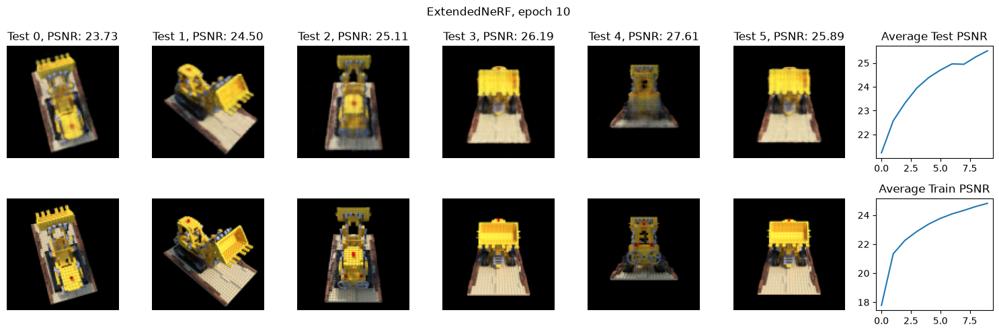

[ExtendedNeRF] epoch  11/100 | train PSNR  25.04 | test PSNR  25.72 |  55.2 s


[ExtendedNeRF] epoch  12/100 | train PSNR  25.22 | test PSNR  25.89 |  54.9 s


[ExtendedNeRF] epoch  13/100 | train PSNR  25.40 | test PSNR  26.14 |  55.1 s


[ExtendedNeRF] epoch  14/100 | train PSNR  25.57 | test PSNR  26.08 |  54.9 s


[ExtendedNeRF] epoch  15/100 | train PSNR  25.69 | test PSNR  26.16 |  54.7 s


[ExtendedNeRF] epoch  16/100 | train PSNR  25.82 | test PSNR  26.50 |  55.3 s


[ExtendedNeRF] epoch  17/100 | train PSNR  25.95 | test PSNR  26.53 |  54.7 s


[ExtendedNeRF] epoch  18/100 | train PSNR  26.06 | test PSNR  26.60 |  55.4 s


[ExtendedNeRF] epoch  19/100 | train PSNR  26.16 | test PSNR  26.75 |  54.9 s


[ExtendedNeRF] epoch  20/100 | train PSNR  26.27 | test PSNR  26.71 |  55.1 s


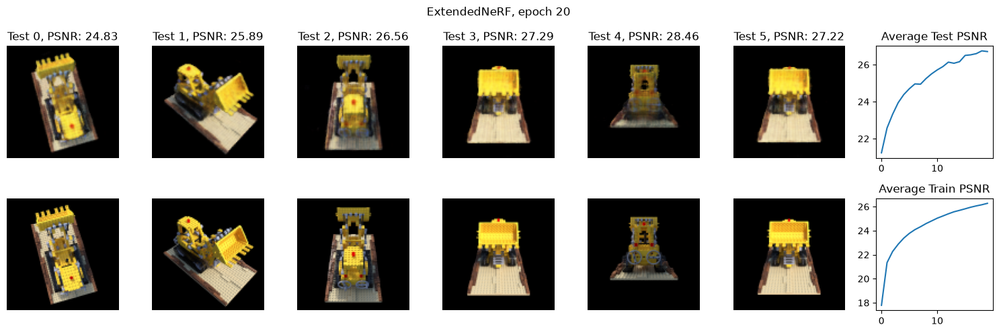

[ExtendedNeRF] epoch  21/100 | train PSNR  26.38 | test PSNR  26.69 |  51.9 s


[ExtendedNeRF] epoch  22/100 | train PSNR  26.45 | test PSNR  26.91 |  55.2 s


[ExtendedNeRF] epoch  23/100 | train PSNR  26.54 | test PSNR  27.09 |  55.4 s


[ExtendedNeRF] epoch  24/100 | train PSNR  26.61 | test PSNR  26.92 |  55.0 s


[ExtendedNeRF] epoch  25/100 | train PSNR  26.68 | test PSNR  27.09 |  54.7 s


[ExtendedNeRF] epoch  26/100 | train PSNR  26.73 | test PSNR  27.24 |  54.7 s


[ExtendedNeRF] epoch  27/100 | train PSNR  26.80 | test PSNR  27.22 |  55.0 s


[ExtendedNeRF] epoch  28/100 | train PSNR  26.86 | test PSNR  27.11 |  54.9 s


[ExtendedNeRF] epoch  29/100 | train PSNR  26.93 | test PSNR  27.26 |  55.1 s


[ExtendedNeRF] epoch  30/100 | train PSNR  26.97 | test PSNR  27.41 |  55.1 s


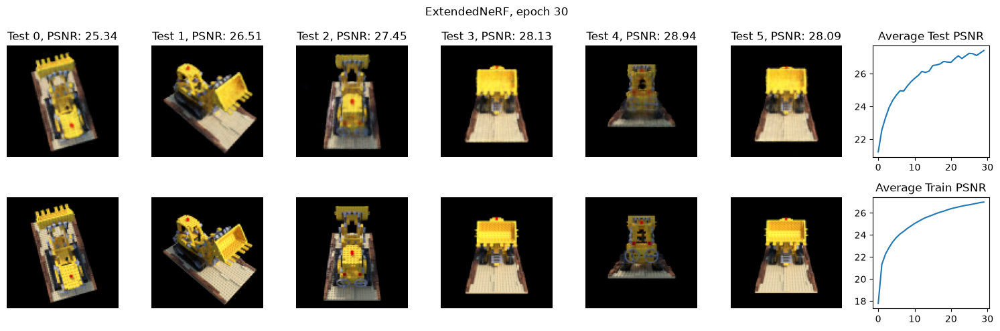

[ExtendedNeRF] epoch  31/100 | train PSNR  27.03 | test PSNR  27.38 |  54.7 s


[ExtendedNeRF] epoch  32/100 | train PSNR  27.07 | test PSNR  27.45 |  55.1 s


[ExtendedNeRF] epoch  33/100 | train PSNR  27.13 | test PSNR  27.52 |  51.8 s


[ExtendedNeRF] epoch  34/100 | train PSNR  27.17 | test PSNR  27.50 |  55.0 s


[ExtendedNeRF] epoch  35/100 | train PSNR  27.20 | test PSNR  27.76 |  54.0 s


[ExtendedNeRF] epoch  36/100 | train PSNR  27.25 | test PSNR  27.72 |  54.6 s


[ExtendedNeRF] epoch  37/100 | train PSNR  27.27 | test PSNR  27.67 |  55.1 s


[ExtendedNeRF] epoch  38/100 | train PSNR  27.35 | test PSNR  27.66 |  54.6 s


[ExtendedNeRF] epoch  39/100 | train PSNR  27.36 | test PSNR  27.70 |  54.8 s


[ExtendedNeRF] epoch  40/100 | train PSNR  27.38 | test PSNR  27.85 |  54.5 s


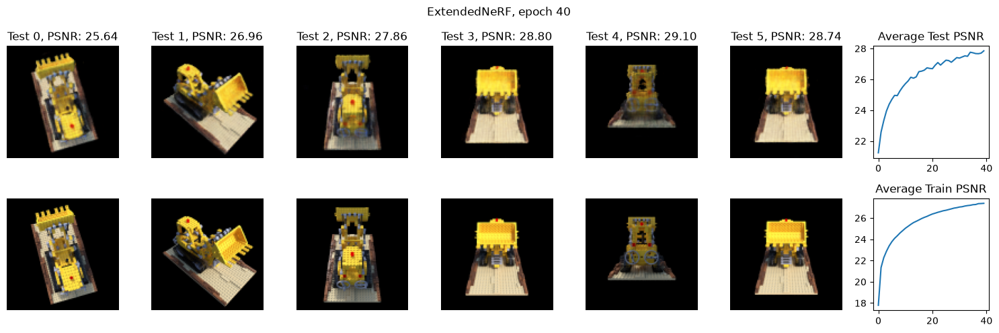

[ExtendedNeRF] epoch  41/100 | train PSNR  27.42 | test PSNR  27.82 |  54.9 s


[ExtendedNeRF] epoch  42/100 | train PSNR  27.44 | test PSNR  27.68 |  55.0 s


[ExtendedNeRF] epoch  43/100 | train PSNR  27.49 | test PSNR  27.80 |  54.3 s


[ExtendedNeRF] epoch  44/100 | train PSNR  27.53 | test PSNR  27.67 |  55.0 s


[ExtendedNeRF] epoch  45/100 | train PSNR  27.55 | test PSNR  27.78 |  50.5 s


[ExtendedNeRF] epoch  46/100 | train PSNR  27.60 | test PSNR  27.97 |  51.6 s


[ExtendedNeRF] epoch  47/100 | train PSNR  27.63 | test PSNR  27.77 |  51.8 s


[ExtendedNeRF] epoch  48/100 | train PSNR  27.64 | test PSNR  27.71 |  51.8 s


[ExtendedNeRF] epoch  49/100 | train PSNR  27.67 | test PSNR  27.91 |  52.2 s


[ExtendedNeRF] epoch  50/100 | train PSNR  27.70 | test PSNR  27.86 |  52.0 s


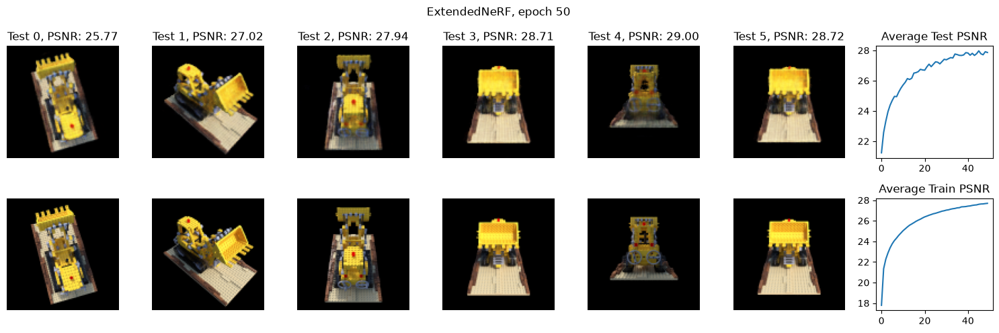

[ExtendedNeRF] epoch  51/100 | train PSNR  27.70 | test PSNR  28.09 |  51.8 s


[ExtendedNeRF] epoch  52/100 | train PSNR  27.74 | test PSNR  27.99 |  52.1 s


[ExtendedNeRF] epoch  53/100 | train PSNR  27.76 | test PSNR  27.94 |  51.7 s


[ExtendedNeRF] epoch  54/100 | train PSNR  27.78 | test PSNR  28.09 |  52.4 s


[ExtendedNeRF] epoch  55/100 | train PSNR  27.79 | test PSNR  28.14 |  52.4 s


[ExtendedNeRF] epoch  56/100 | train PSNR  27.82 | test PSNR  28.09 |  49.7 s


[ExtendedNeRF] epoch  57/100 | train PSNR  27.86 | test PSNR  28.01 |  51.8 s


[ExtendedNeRF] epoch  58/100 | train PSNR  27.86 | test PSNR  28.21 |  51.8 s


[ExtendedNeRF] epoch  59/100 | train PSNR  27.89 | test PSNR  28.18 |  51.8 s


[ExtendedNeRF] epoch  60/100 | train PSNR  27.90 | test PSNR  28.11 |  51.9 s


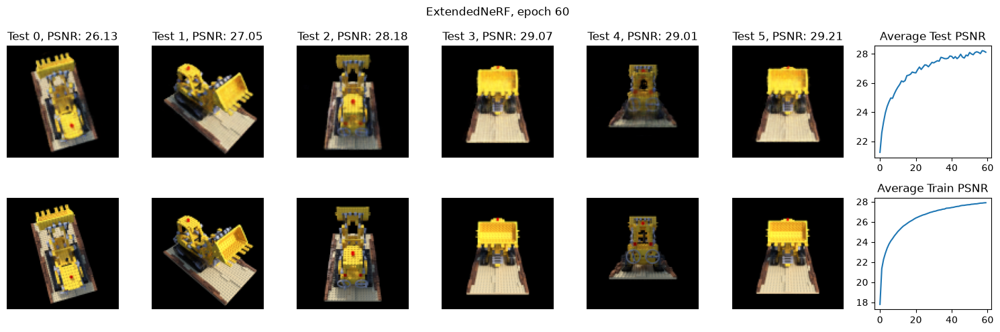

[ExtendedNeRF] epoch  61/100 | train PSNR  27.93 | test PSNR  28.21 |  52.1 s


[ExtendedNeRF] epoch  62/100 | train PSNR  27.95 | test PSNR  28.21 |  52.2 s


[ExtendedNeRF] epoch  63/100 | train PSNR  27.97 | test PSNR  28.20 |  52.3 s


[ExtendedNeRF] epoch  64/100 | train PSNR  27.98 | test PSNR  28.25 |  52.5 s


[ExtendedNeRF] epoch  65/100 | train PSNR  28.00 | test PSNR  28.21 |  52.1 s


[ExtendedNeRF] epoch  66/100 | train PSNR  28.01 | test PSNR  28.18 |  49.8 s


[ExtendedNeRF] epoch  67/100 | train PSNR  28.04 | test PSNR  28.37 |  51.7 s


[ExtendedNeRF] epoch  68/100 | train PSNR  28.02 | test PSNR  28.25 |  51.6 s


[ExtendedNeRF] epoch  69/100 | train PSNR  28.07 | test PSNR  28.23 |  51.8 s


[ExtendedNeRF] epoch  70/100 | train PSNR  28.07 | test PSNR  28.35 |  52.1 s


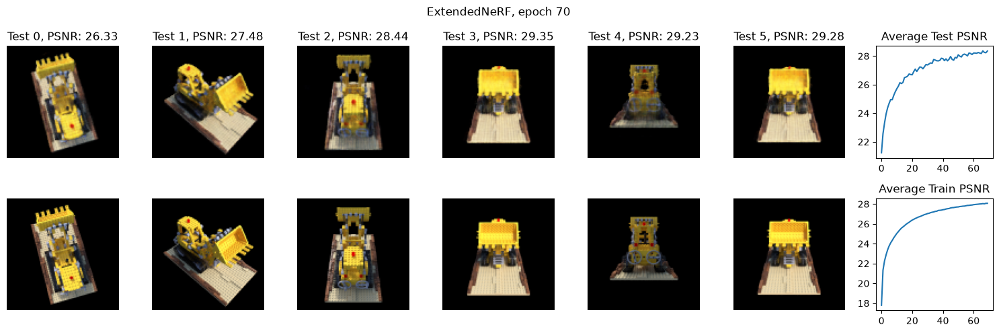

[ExtendedNeRF] epoch  71/100 | train PSNR  28.08 | test PSNR  28.36 |  52.1 s


[ExtendedNeRF] epoch  72/100 | train PSNR  28.12 | test PSNR  28.37 |  52.4 s


[ExtendedNeRF] epoch  73/100 | train PSNR  28.10 | test PSNR  28.23 |  52.4 s


[ExtendedNeRF] epoch  74/100 | train PSNR  28.10 | test PSNR  28.43 |  52.1 s


[ExtendedNeRF] epoch  75/100 | train PSNR  28.15 | test PSNR  28.40 |  52.0 s


[ExtendedNeRF] epoch  76/100 | train PSNR  28.15 | test PSNR  28.37 |  51.9 s


[ExtendedNeRF] epoch  77/100 | train PSNR  28.16 | test PSNR  28.28 |  38.6 s


[ExtendedNeRF] epoch  78/100 | train PSNR  28.18 | test PSNR  28.39 |  34.7 s


[ExtendedNeRF] epoch  79/100 | train PSNR  28.19 | test PSNR  28.40 |  34.7 s


[ExtendedNeRF] epoch  80/100 | train PSNR  28.19 | test PSNR  28.26 |  34.7 s


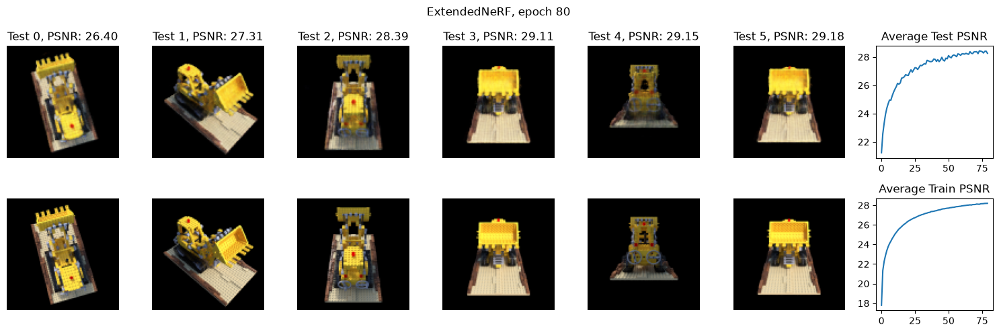

[ExtendedNeRF] epoch  81/100 | train PSNR  28.22 | test PSNR  28.32 |  34.7 s


[ExtendedNeRF] epoch  82/100 | train PSNR  28.22 | test PSNR  28.42 |  34.7 s


[ExtendedNeRF] epoch  83/100 | train PSNR  28.23 | test PSNR  28.36 |  34.7 s


[ExtendedNeRF] epoch  84/100 | train PSNR  28.26 | test PSNR  28.43 |  34.7 s


[ExtendedNeRF] epoch  85/100 | train PSNR  28.26 | test PSNR  28.36 |  34.7 s


[ExtendedNeRF] epoch  86/100 | train PSNR  28.26 | test PSNR  28.26 |  34.7 s


[ExtendedNeRF] epoch  87/100 | train PSNR  28.27 | test PSNR  28.46 |  34.7 s


[ExtendedNeRF] epoch  88/100 | train PSNR  28.28 | test PSNR  28.35 |  34.9 s


[ExtendedNeRF] epoch  89/100 | train PSNR  28.29 | test PSNR  28.34 |  55.5 s


[ExtendedNeRF] epoch  90/100 | train PSNR  28.31 | test PSNR  28.44 |  44.9 s


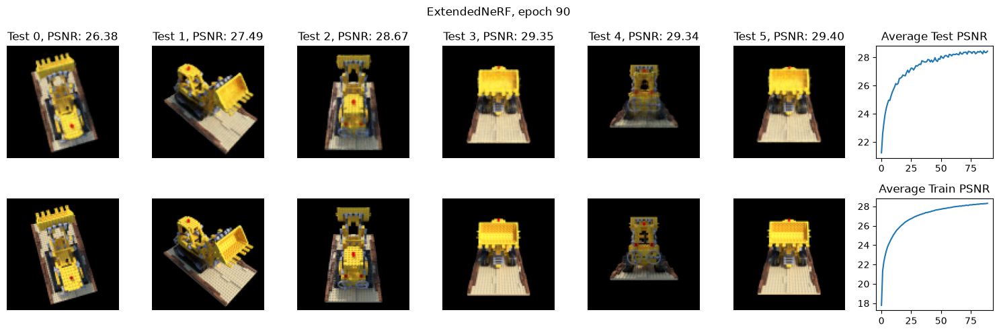

[ExtendedNeRF] epoch  91/100 | train PSNR  28.31 | test PSNR  28.46 |  34.7 s


[ExtendedNeRF] epoch  92/100 | train PSNR  28.31 | test PSNR  28.50 |  34.7 s


[ExtendedNeRF] epoch  93/100 | train PSNR  28.31 | test PSNR  28.52 |  34.7 s


[ExtendedNeRF] epoch  94/100 | train PSNR  28.32 | test PSNR  28.37 |  34.7 s


[ExtendedNeRF] epoch  95/100 | train PSNR  28.33 | test PSNR  28.51 |  34.7 s


[ExtendedNeRF] epoch  96/100 | train PSNR  28.33 | test PSNR  28.54 |  34.7 s


[ExtendedNeRF] epoch  97/100 | train PSNR  28.35 | test PSNR  28.37 |  34.7 s


[ExtendedNeRF] epoch  98/100 | train PSNR  28.37 | test PSNR  28.47 |  34.7 s


[ExtendedNeRF] epoch  99/100 | train PSNR  28.37 | test PSNR  28.49 |  34.7 s


[ExtendedNeRF] epoch 100/100 | train PSNR  28.38 | test PSNR  28.44 |  34.7 s


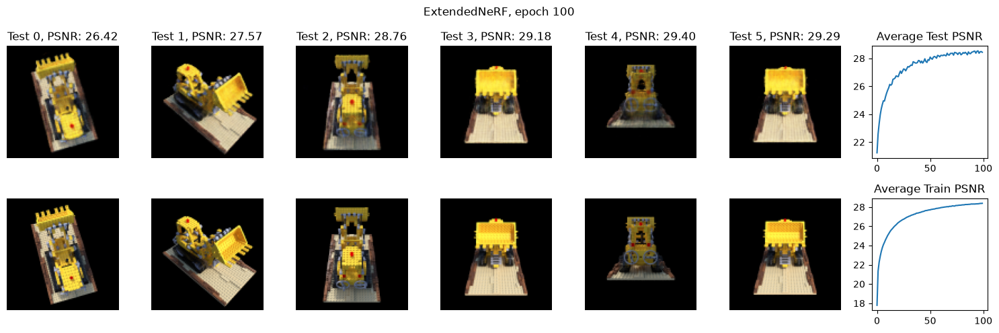

ExtendedNeRF final test PSNR: 28.44 dB | mean epoch time 49.1 s


In [15]:
# Initialize the coarse and fine networks and train them jointly (loss = coarse MSE + fine MSE)
model_coarse = NeRF(filter_size=128, L_embed=6).to(device)
model_fine = NeRF(filter_size=128, L_embed=6).to(device)
print(model_fine)
print("trainable parameters per network:", sum(p.numel() for p in model_fine.parameters()))

render_train = lambda rays_o, rays_d: list(render_rays(model_coarse, model_fine, rays_o, rays_d,
                                                       NEAR, FAR, N_C, N_F, rand=True))
render_test = lambda rays_o, rays_d: render_rays(model_coarse, model_fine, rays_o, rays_d,
                                                 NEAR, FAR, N_C, N_F, rand=False)[1]

history = train("ExtendedNeRF", [model_coarse, model_fine], render_train, render_test, N_EPOCHS)
print(f"ExtendedNeRF final test PSNR: {history['test_psnr'][-1]:.2f} dB | "
      f"mean epoch time {np.mean(history['epoch_seconds']):.1f} s")

Save the trained weights and this model's per-epoch history for `main_report.ipynb`, which reloads
them instead of training again.

In [16]:
# Save both networks and the training history for main_report.ipynb
torch.save({"coarse": model_coarse.state_dict(), "fine": model_fine.state_dict(),
            "config": {"filter_size": 128, "L_embed": 6, "L_dir": 4, "N_c": N_C, "N_f": N_F,
                       "view_dependent": True, "epochs": N_EPOCHS, "seed": SEED}}, "extended_nerf.pth")
save_history("ExtendedNeRF", history)
print("saved extended_nerf.pth and training_history.json")

saved extended_nerf.pth and training_history.json


## Interactive Visualization: Novel View Synthesis

In [17]:
# Interactive novel-view synthesis (Tutorial 10.4). The camera sits on a sphere around the object;
# theta = azimuth, phi = elevation, radius = distance.
trans_t = lambda t: torch.tensor([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, t],
    [0, 0, 0, 1],
], dtype=torch.float32)

# Rotation about x-axis (phi)
rot_phi = lambda phi: torch.tensor([
    [1, 0, 0, 0],
    [0, torch.cos(phi), -torch.sin(phi), 0],
    [0, torch.sin(phi),  torch.cos(phi), 0],
    [0, 0, 0, 1],
], dtype=torch.float32)

# Rotation about y-axis (theta)
rot_theta = lambda th: torch.tensor([
    [torch.cos(th), 0, -torch.sin(th), 0],
    [0, 1, 0, 0],
    [torch.sin(th), 0,  torch.cos(th), 0],
    [0, 0, 0, 1],
], dtype=torch.float32)

def pose_spherical(theta, phi, radius):
    c2w = trans_t(radius)
    c2w = rot_phi(torch.tensor(phi / 180. * np.pi)) @ c2w
    c2w = rot_theta(torch.tensor(theta / 180. * np.pi)) @ c2w
    c2w = torch.tensor([
        [-1, 0, 0, 0],
        [ 0, 0, 1, 0],
        [ 0, 1, 0, 0],
        [ 0, 0, 0, 1],
    ], dtype=torch.float32) @ c2w
    return c2w.to(device)

The tutorial's interactive viewer: sliders move the camera over a sphere around the object, which
needs a live kernel with `ipywidgets` (a stored notebook shows a placeholder instead).

In [18]:
# Interactive viewer with the fine network (the starter's version passed only model_fine to
# render_rays, which needs both networks; fixed here). Falls back to one static render.
render_novel = lambda rays_o, rays_d: render_rays(model_coarse, model_fine, rays_o, rays_d,
                                                  NEAR, FAR, N_C, N_F, rand=False)[1]

def f(**kwargs):
    img = render_image(render_novel, pose_spherical(**kwargs)).clamp(0, 1).cpu().numpy()
    plt.figure(2, figsize=(20, 6)); plt.imshow(img); plt.axis('off'); plt.show()

try:
    from ipywidgets import interactive, widgets
    sldr = lambda v, mi, ma: widgets.FloatSlider(value=v, min=mi, max=ma, step=0.01)
    names = [['theta', [100., 0., 360.]], ['phi', [-30., -90., 0.]], ['radius', [4., 3., 5.]]]
    interactive_plot = interactive(f, **{s[0]: sldr(*s[1]) for s in names})
    interactive_plot.children[-1].layout.height = '350px'
    display(interactive_plot)
except ImportError:
    f(theta=100., phi=-30., radius=4.)

interactive(children=(FloatSlider(value=100.0, description='theta', max=360.0, step=0.01), FloatSlider(value=-…

# Ablation study

To separate the contribution of each upgrade, two more models are trained with exactly the same
epochs, learning-rate schedule, seed and batches:

| model | view-dependent colour | hierarchical sampling | points per ray seen by the final network |
|---|---|---|---|
| Tiny NeRF (baseline, `TinyNeRF.ipynb`) | no | no (64 uniform) | 64 |
| **Extended NeRF** (above) | yes | yes (32 coarse + 64 fine) | 96 |
| Ablation A: no view directions | no (direction input set to 0) | yes (32 + 64) | 96 |
| Ablation B: uniform sampling | yes | no (96 uniform, one network) | 96 |

Ablation A keeps the Extended architecture but removes view dependence; Ablation B keeps view
dependence but replaces hierarchical sampling with the same number of uniform samples, so the
fine network's sample count is matched.

[Ablation_NoViewDirs] epoch   1/100 | train PSNR  17.85 | test PSNR  21.12 |  35.1 s


[Ablation_NoViewDirs] epoch   2/100 | train PSNR  21.06 | test PSNR  22.39 |  34.9 s


[Ablation_NoViewDirs] epoch   3/100 | train PSNR  21.95 | test PSNR  23.04 |  34.9 s


[Ablation_NoViewDirs] epoch   4/100 | train PSNR  22.50 | test PSNR  23.49 |  34.8 s


[Ablation_NoViewDirs] epoch   5/100 | train PSNR  22.90 | test PSNR  23.92 |  34.8 s


[Ablation_NoViewDirs] epoch   6/100 | train PSNR  23.21 | test PSNR  24.03 |  34.8 s


[Ablation_NoViewDirs] epoch   7/100 | train PSNR  23.43 | test PSNR  24.42 |  34.7 s


[Ablation_NoViewDirs] epoch   8/100 | train PSNR  23.61 | test PSNR  24.46 |  34.7 s


[Ablation_NoViewDirs] epoch   9/100 | train PSNR  23.76 | test PSNR  24.55 |  34.7 s


[Ablation_NoViewDirs] epoch  10/100 | train PSNR  23.89 | test PSNR  24.79 |  34.7 s


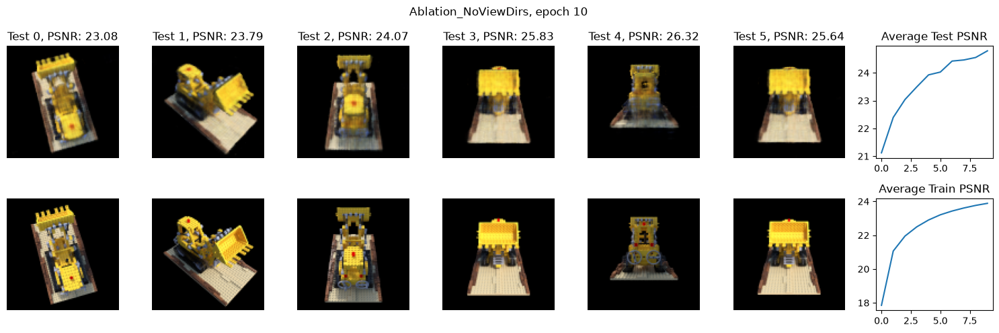

[Ablation_NoViewDirs] epoch  11/100 | train PSNR  24.00 | test PSNR  24.85 |  34.7 s


[Ablation_NoViewDirs] epoch  12/100 | train PSNR  24.12 | test PSNR  24.82 |  34.7 s


[Ablation_NoViewDirs] epoch  13/100 | train PSNR  24.22 | test PSNR  25.01 |  34.7 s


[Ablation_NoViewDirs] epoch  14/100 | train PSNR  24.33 | test PSNR  24.95 |  34.7 s


[Ablation_NoViewDirs] epoch  15/100 | train PSNR  24.41 | test PSNR  25.12 |  34.7 s


[Ablation_NoViewDirs] epoch  16/100 | train PSNR  24.52 | test PSNR  25.06 |  34.7 s


[Ablation_NoViewDirs] epoch  17/100 | train PSNR  24.59 | test PSNR  25.32 |  34.7 s


[Ablation_NoViewDirs] epoch  18/100 | train PSNR  24.66 | test PSNR  25.34 |  34.6 s


[Ablation_NoViewDirs] epoch  19/100 | train PSNR  24.72 | test PSNR  25.24 |  34.7 s


[Ablation_NoViewDirs] epoch  20/100 | train PSNR  24.80 | test PSNR  25.64 |  34.6 s


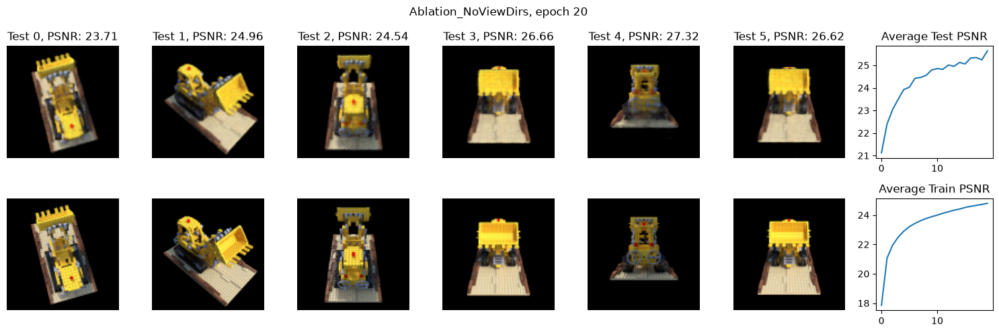

[Ablation_NoViewDirs] epoch  21/100 | train PSNR  24.84 | test PSNR  25.42 |  34.6 s


[Ablation_NoViewDirs] epoch  22/100 | train PSNR  24.88 | test PSNR  25.45 |  34.6 s


[Ablation_NoViewDirs] epoch  23/100 | train PSNR  24.94 | test PSNR  25.65 |  34.6 s


[Ablation_NoViewDirs] epoch  24/100 | train PSNR  24.99 | test PSNR  25.57 |  34.6 s


[Ablation_NoViewDirs] epoch  25/100 | train PSNR  25.03 | test PSNR  25.57 |  34.6 s


[Ablation_NoViewDirs] epoch  26/100 | train PSNR  25.06 | test PSNR  25.68 |  34.6 s


[Ablation_NoViewDirs] epoch  27/100 | train PSNR  25.09 | test PSNR  25.77 |  34.6 s


[Ablation_NoViewDirs] epoch  28/100 | train PSNR  25.14 | test PSNR  25.70 |  34.6 s


[Ablation_NoViewDirs] epoch  29/100 | train PSNR  25.18 | test PSNR  25.74 |  34.6 s


[Ablation_NoViewDirs] epoch  30/100 | train PSNR  25.21 | test PSNR  25.78 |  34.6 s


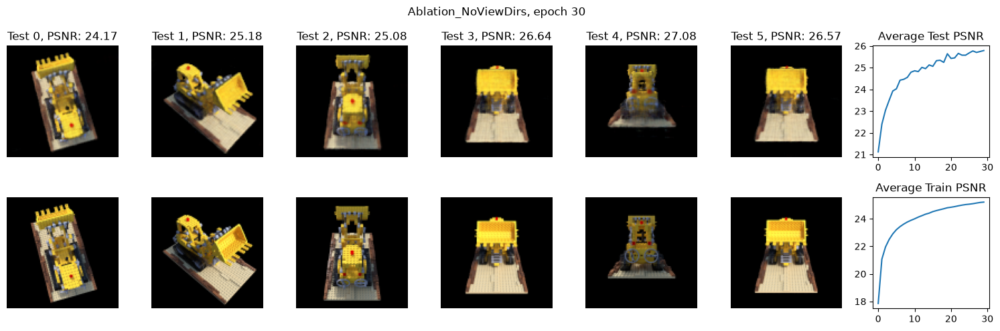

[Ablation_NoViewDirs] epoch  31/100 | train PSNR  25.24 | test PSNR  25.79 |  34.6 s


[Ablation_NoViewDirs] epoch  32/100 | train PSNR  25.27 | test PSNR  25.87 |  34.6 s


[Ablation_NoViewDirs] epoch  33/100 | train PSNR  25.28 | test PSNR  25.93 |  34.6 s


[Ablation_NoViewDirs] epoch  34/100 | train PSNR  25.33 | test PSNR  25.89 |  34.6 s


[Ablation_NoViewDirs] epoch  35/100 | train PSNR  25.36 | test PSNR  25.85 |  34.6 s


[Ablation_NoViewDirs] epoch  36/100 | train PSNR  25.39 | test PSNR  26.02 |  34.6 s


[Ablation_NoViewDirs] epoch  37/100 | train PSNR  25.39 | test PSNR  25.87 |  34.6 s


[Ablation_NoViewDirs] epoch  38/100 | train PSNR  25.43 | test PSNR  25.95 |  34.6 s


[Ablation_NoViewDirs] epoch  39/100 | train PSNR  25.45 | test PSNR  26.06 |  34.6 s


[Ablation_NoViewDirs] epoch  40/100 | train PSNR  25.44 | test PSNR  25.97 |  34.6 s


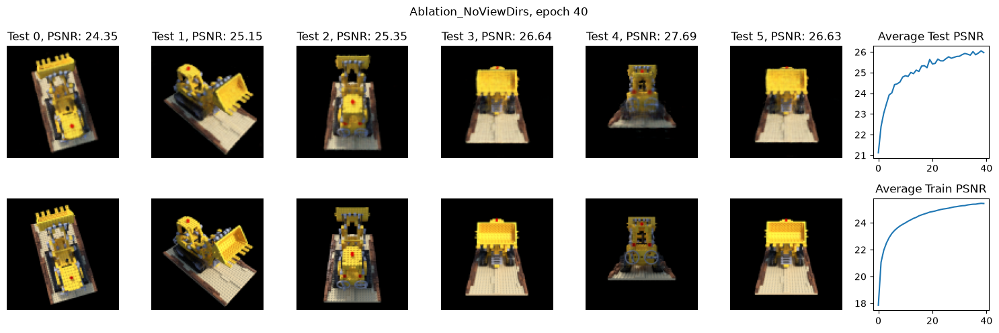

[Ablation_NoViewDirs] epoch  41/100 | train PSNR  25.46 | test PSNR  26.05 |  34.6 s


[Ablation_NoViewDirs] epoch  42/100 | train PSNR  25.49 | test PSNR  25.94 |  34.6 s


[Ablation_NoViewDirs] epoch  43/100 | train PSNR  25.50 | test PSNR  26.03 |  34.6 s


[Ablation_NoViewDirs] epoch  44/100 | train PSNR  25.52 | test PSNR  26.03 |  34.6 s


[Ablation_NoViewDirs] epoch  45/100 | train PSNR  25.52 | test PSNR  26.10 |  34.6 s


[Ablation_NoViewDirs] epoch  46/100 | train PSNR  25.54 | test PSNR  26.18 |  34.6 s


[Ablation_NoViewDirs] epoch  47/100 | train PSNR  25.58 | test PSNR  26.02 |  34.6 s


[Ablation_NoViewDirs] epoch  48/100 | train PSNR  25.58 | test PSNR  26.06 |  34.6 s


[Ablation_NoViewDirs] epoch  49/100 | train PSNR  25.59 | test PSNR  25.96 |  34.6 s


[Ablation_NoViewDirs] epoch  50/100 | train PSNR  25.60 | test PSNR  26.16 |  34.6 s


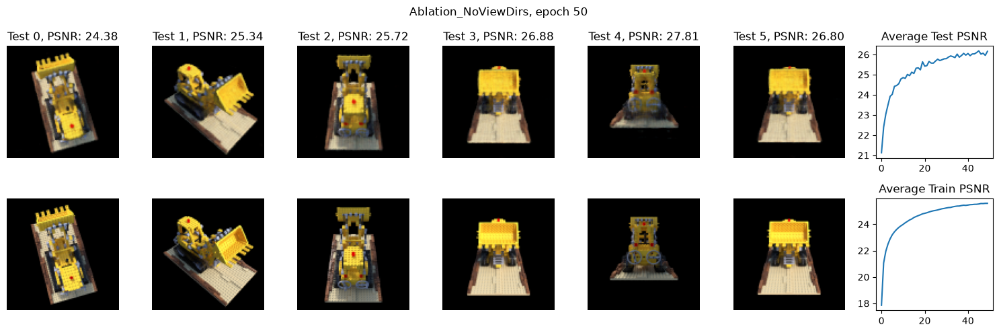

[Ablation_NoViewDirs] epoch  51/100 | train PSNR  25.61 | test PSNR  26.22 |  34.6 s


[Ablation_NoViewDirs] epoch  52/100 | train PSNR  25.61 | test PSNR  26.12 |  34.6 s


[Ablation_NoViewDirs] epoch  53/100 | train PSNR  25.63 | test PSNR  26.08 |  34.6 s


[Ablation_NoViewDirs] epoch  54/100 | train PSNR  25.66 | test PSNR  26.19 |  34.6 s


[Ablation_NoViewDirs] epoch  55/100 | train PSNR  25.66 | test PSNR  26.17 |  34.6 s


[Ablation_NoViewDirs] epoch  56/100 | train PSNR  25.68 | test PSNR  26.19 |  34.6 s


[Ablation_NoViewDirs] epoch  57/100 | train PSNR  25.69 | test PSNR  26.19 |  34.6 s


[Ablation_NoViewDirs] epoch  58/100 | train PSNR  25.67 | test PSNR  26.20 |  34.6 s


[Ablation_NoViewDirs] epoch  59/100 | train PSNR  25.70 | test PSNR  26.20 |  34.6 s


[Ablation_NoViewDirs] epoch  60/100 | train PSNR  25.72 | test PSNR  26.24 |  34.6 s


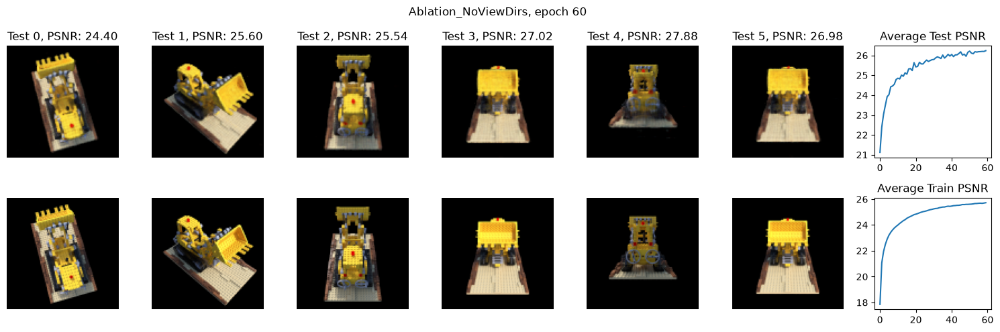

[Ablation_NoViewDirs] epoch  61/100 | train PSNR  25.71 | test PSNR  26.22 |  34.5 s


[Ablation_NoViewDirs] epoch  62/100 | train PSNR  25.73 | test PSNR  26.27 |  34.4 s


[Ablation_NoViewDirs] epoch  63/100 | train PSNR  25.75 | test PSNR  26.27 |  34.4 s


[Ablation_NoViewDirs] epoch  64/100 | train PSNR  25.76 | test PSNR  26.31 |  34.3 s


[Ablation_NoViewDirs] epoch  65/100 | train PSNR  25.76 | test PSNR  26.22 |  34.3 s


[Ablation_NoViewDirs] epoch  66/100 | train PSNR  25.77 | test PSNR  26.26 |  34.3 s


[Ablation_NoViewDirs] epoch  67/100 | train PSNR  25.78 | test PSNR  26.29 |  34.3 s


[Ablation_NoViewDirs] epoch  68/100 | train PSNR  25.76 | test PSNR  26.27 |  34.3 s


[Ablation_NoViewDirs] epoch  69/100 | train PSNR  25.79 | test PSNR  26.35 |  34.3 s


[Ablation_NoViewDirs] epoch  70/100 | train PSNR  25.80 | test PSNR  26.32 |  34.3 s


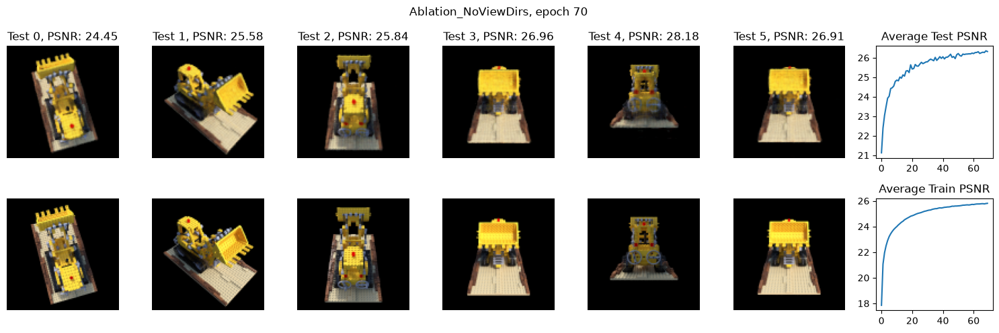

[Ablation_NoViewDirs] epoch  71/100 | train PSNR  25.80 | test PSNR  26.31 |  34.3 s


[Ablation_NoViewDirs] epoch  72/100 | train PSNR  25.80 | test PSNR  26.26 |  34.3 s


[Ablation_NoViewDirs] epoch  73/100 | train PSNR  25.82 | test PSNR  26.36 |  34.3 s


[Ablation_NoViewDirs] epoch  74/100 | train PSNR  25.82 | test PSNR  26.31 |  34.3 s


[Ablation_NoViewDirs] epoch  75/100 | train PSNR  25.81 | test PSNR  26.38 |  34.3 s


[Ablation_NoViewDirs] epoch  76/100 | train PSNR  25.83 | test PSNR  26.35 |  34.3 s


[Ablation_NoViewDirs] epoch  77/100 | train PSNR  25.83 | test PSNR  26.35 |  34.3 s


[Ablation_NoViewDirs] epoch  78/100 | train PSNR  25.83 | test PSNR  26.38 |  34.3 s


[Ablation_NoViewDirs] epoch  79/100 | train PSNR  25.86 | test PSNR  26.38 |  34.3 s


[Ablation_NoViewDirs] epoch  80/100 | train PSNR  25.85 | test PSNR  26.31 |  34.3 s


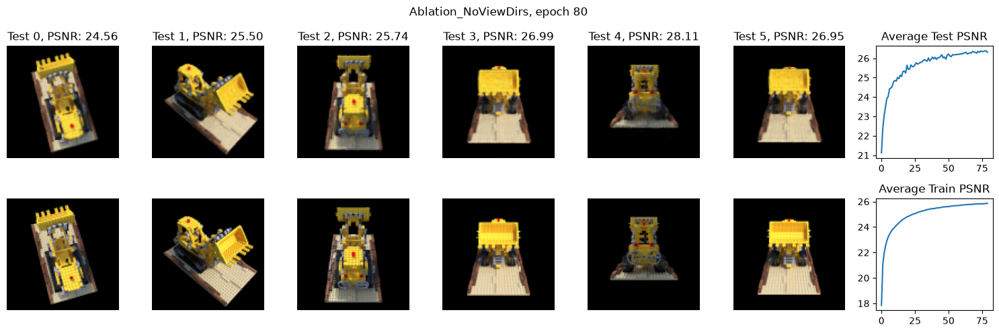

[Ablation_NoViewDirs] epoch  81/100 | train PSNR  25.87 | test PSNR  26.35 |  34.3 s


[Ablation_NoViewDirs] epoch  82/100 | train PSNR  25.86 | test PSNR  26.37 |  34.3 s


[Ablation_NoViewDirs] epoch  83/100 | train PSNR  25.86 | test PSNR  26.22 |  34.2 s


[Ablation_NoViewDirs] epoch  84/100 | train PSNR  25.88 | test PSNR  26.39 |  34.2 s


[Ablation_NoViewDirs] epoch  85/100 | train PSNR  25.88 | test PSNR  26.39 |  34.3 s


[Ablation_NoViewDirs] epoch  86/100 | train PSNR  25.89 | test PSNR  26.37 |  34.3 s


[Ablation_NoViewDirs] epoch  87/100 | train PSNR  25.88 | test PSNR  26.31 |  34.3 s


[Ablation_NoViewDirs] epoch  88/100 | train PSNR  25.90 | test PSNR  26.37 |  34.3 s


[Ablation_NoViewDirs] epoch  89/100 | train PSNR  25.90 | test PSNR  26.38 |  34.3 s


[Ablation_NoViewDirs] epoch  90/100 | train PSNR  25.91 | test PSNR  26.40 |  34.3 s


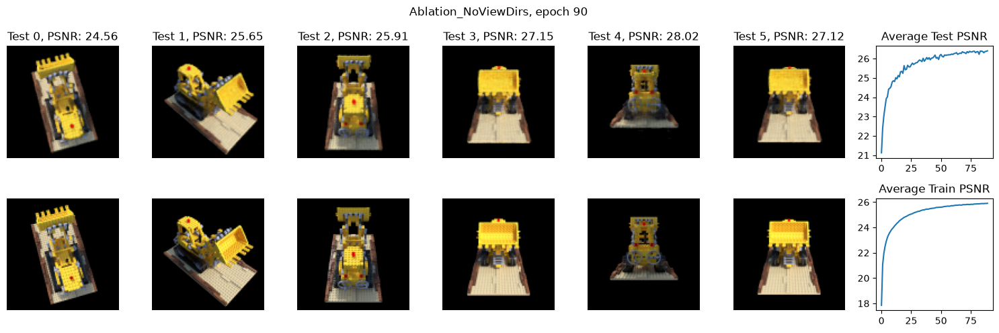

[Ablation_NoViewDirs] epoch  91/100 | train PSNR  25.91 | test PSNR  26.37 |  34.3 s


[Ablation_NoViewDirs] epoch  92/100 | train PSNR  25.91 | test PSNR  26.39 |  34.3 s


[Ablation_NoViewDirs] epoch  93/100 | train PSNR  25.91 | test PSNR  26.44 |  34.3 s


[Ablation_NoViewDirs] epoch  94/100 | train PSNR  25.92 | test PSNR  26.34 |  34.3 s


[Ablation_NoViewDirs] epoch  95/100 | train PSNR  25.92 | test PSNR  26.35 |  34.2 s


[Ablation_NoViewDirs] epoch  96/100 | train PSNR  25.93 | test PSNR  26.47 |  34.3 s


[Ablation_NoViewDirs] epoch  97/100 | train PSNR  25.92 | test PSNR  26.41 |  34.3 s


[Ablation_NoViewDirs] epoch  98/100 | train PSNR  25.93 | test PSNR  26.43 |  34.3 s


[Ablation_NoViewDirs] epoch  99/100 | train PSNR  25.95 | test PSNR  26.33 |  34.3 s


[Ablation_NoViewDirs] epoch 100/100 | train PSNR  25.94 | test PSNR  26.41 |  34.3 s


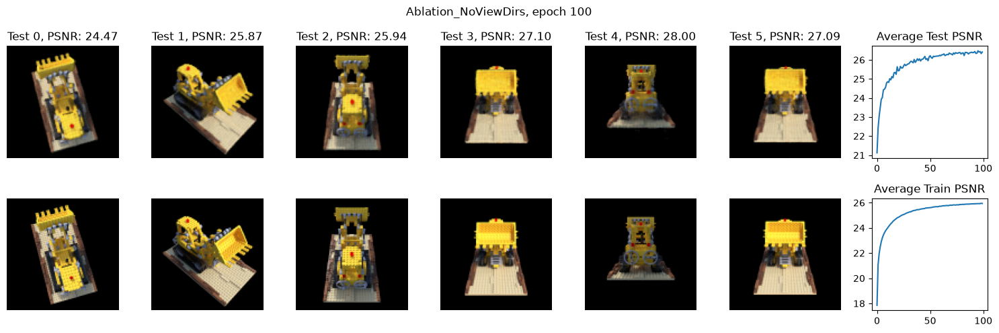

[Ablation_Uniform96] epoch   1/100 | train PSNR  17.88 | test PSNR  21.35 |  25.8 s


[Ablation_Uniform96] epoch   2/100 | train PSNR  21.31 | test PSNR  22.56 |  25.7 s


[Ablation_Uniform96] epoch   3/100 | train PSNR  22.18 | test PSNR  23.24 |  25.7 s


[Ablation_Uniform96] epoch   4/100 | train PSNR  22.77 | test PSNR  23.90 |  25.7 s


[Ablation_Uniform96] epoch   5/100 | train PSNR  23.28 | test PSNR  24.35 |  25.6 s


[Ablation_Uniform96] epoch   6/100 | train PSNR  23.66 | test PSNR  24.56 |  25.6 s


[Ablation_Uniform96] epoch   7/100 | train PSNR  23.98 | test PSNR  24.97 |  25.6 s


[Ablation_Uniform96] epoch   8/100 | train PSNR  24.25 | test PSNR  24.83 |  25.6 s


[Ablation_Uniform96] epoch   9/100 | train PSNR  24.49 | test PSNR  25.12 |  25.6 s


[Ablation_Uniform96] epoch  10/100 | train PSNR  24.70 | test PSNR  25.32 |  25.6 s


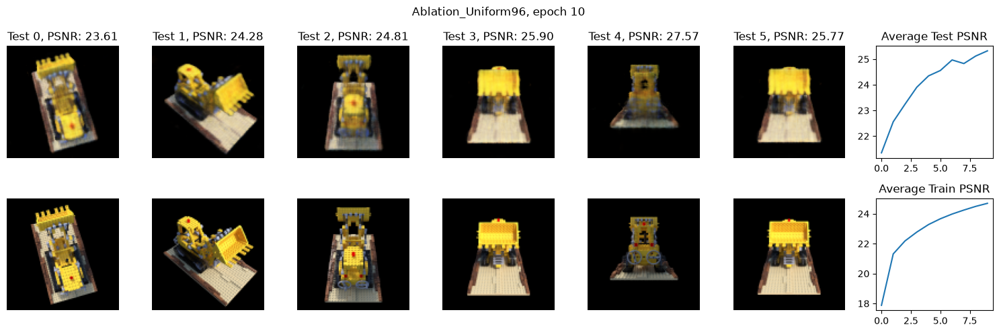

[Ablation_Uniform96] epoch  11/100 | train PSNR  24.89 | test PSNR  25.57 |  25.6 s


[Ablation_Uniform96] epoch  12/100 | train PSNR  25.05 | test PSNR  25.73 |  25.6 s


[Ablation_Uniform96] epoch  13/100 | train PSNR  25.22 | test PSNR  25.69 |  25.6 s


[Ablation_Uniform96] epoch  14/100 | train PSNR  25.39 | test PSNR  25.94 |  25.6 s


[Ablation_Uniform96] epoch  15/100 | train PSNR  25.53 | test PSNR  25.93 |  25.6 s


[Ablation_Uniform96] epoch  16/100 | train PSNR  25.66 | test PSNR  25.87 |  25.6 s


[Ablation_Uniform96] epoch  17/100 | train PSNR  25.77 | test PSNR  26.32 |  25.6 s


[Ablation_Uniform96] epoch  18/100 | train PSNR  25.85 | test PSNR  26.39 |  25.6 s


[Ablation_Uniform96] epoch  19/100 | train PSNR  25.97 | test PSNR  26.53 |  25.6 s


[Ablation_Uniform96] epoch  20/100 | train PSNR  26.07 | test PSNR  26.41 |  25.6 s


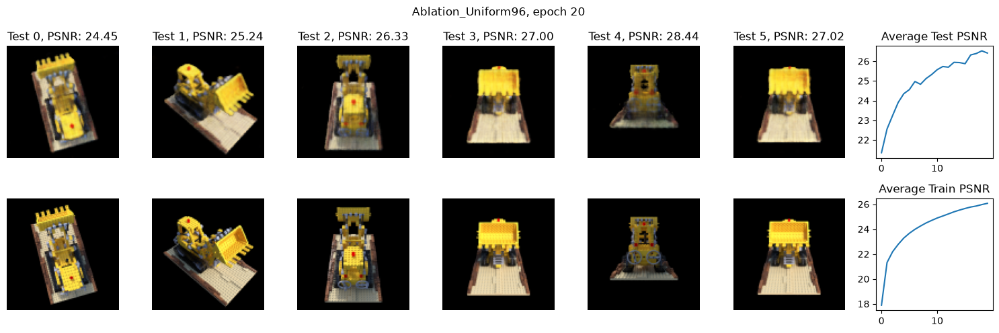

[Ablation_Uniform96] epoch  21/100 | train PSNR  26.14 | test PSNR  26.71 |  25.6 s


[Ablation_Uniform96] epoch  22/100 | train PSNR  26.21 | test PSNR  26.71 |  25.6 s


[Ablation_Uniform96] epoch  23/100 | train PSNR  26.29 | test PSNR  26.90 |  25.6 s


[Ablation_Uniform96] epoch  24/100 | train PSNR  26.38 | test PSNR  26.79 |  25.6 s


[Ablation_Uniform96] epoch  25/100 | train PSNR  26.44 | test PSNR  26.95 |  25.6 s


[Ablation_Uniform96] epoch  26/100 | train PSNR  26.48 | test PSNR  27.03 |  25.6 s


[Ablation_Uniform96] epoch  27/100 | train PSNR  26.53 | test PSNR  27.07 |  25.6 s


[Ablation_Uniform96] epoch  28/100 | train PSNR  26.61 | test PSNR  27.00 |  25.6 s


[Ablation_Uniform96] epoch  29/100 | train PSNR  26.65 | test PSNR  27.21 |  25.6 s


[Ablation_Uniform96] epoch  30/100 | train PSNR  26.69 | test PSNR  27.09 |  25.6 s


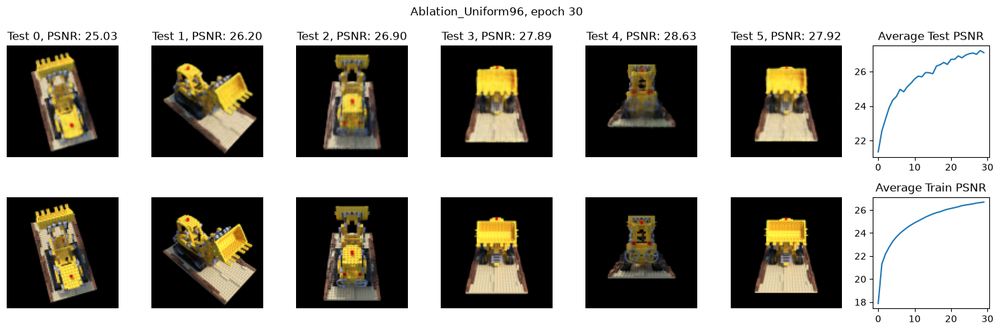

[Ablation_Uniform96] epoch  31/100 | train PSNR  26.75 | test PSNR  27.35 |  25.6 s


[Ablation_Uniform96] epoch  32/100 | train PSNR  26.78 | test PSNR  27.29 |  25.7 s


[Ablation_Uniform96] epoch  33/100 | train PSNR  26.83 | test PSNR  27.41 |  25.7 s


[Ablation_Uniform96] epoch  34/100 | train PSNR  26.87 | test PSNR  27.44 |  25.7 s


[Ablation_Uniform96] epoch  35/100 | train PSNR  26.90 | test PSNR  27.49 |  25.7 s


[Ablation_Uniform96] epoch  36/100 | train PSNR  26.96 | test PSNR  27.44 |  25.7 s


[Ablation_Uniform96] epoch  37/100 | train PSNR  26.98 | test PSNR  27.56 |  25.8 s


[Ablation_Uniform96] epoch  38/100 | train PSNR  27.01 | test PSNR  27.54 |  25.8 s


[Ablation_Uniform96] epoch  39/100 | train PSNR  27.05 | test PSNR  27.72 |  25.8 s


[Ablation_Uniform96] epoch  40/100 | train PSNR  27.09 | test PSNR  27.59 |  25.8 s


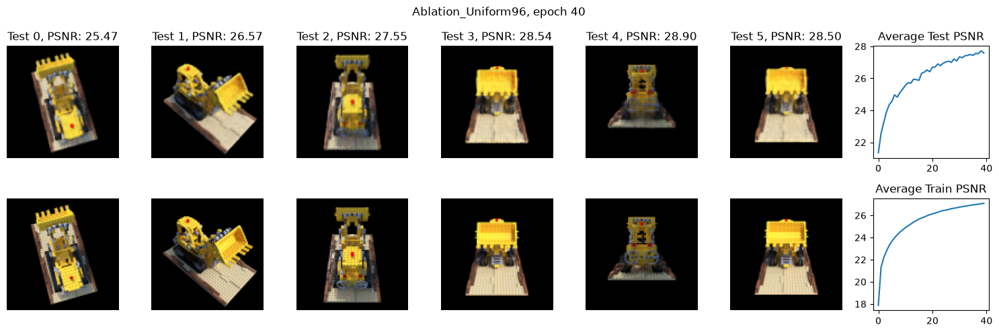

[Ablation_Uniform96] epoch  41/100 | train PSNR  27.11 | test PSNR  27.71 |  25.8 s


[Ablation_Uniform96] epoch  42/100 | train PSNR  27.15 | test PSNR  27.56 |  25.8 s


[Ablation_Uniform96] epoch  43/100 | train PSNR  27.18 | test PSNR  27.64 |  25.8 s


[Ablation_Uniform96] epoch  44/100 | train PSNR  27.19 | test PSNR  27.70 |  25.8 s


[Ablation_Uniform96] epoch  45/100 | train PSNR  27.21 | test PSNR  27.81 |  25.8 s


[Ablation_Uniform96] epoch  46/100 | train PSNR  27.25 | test PSNR  27.86 |  25.8 s


[Ablation_Uniform96] epoch  47/100 | train PSNR  27.28 | test PSNR  27.80 |  25.8 s


[Ablation_Uniform96] epoch  48/100 | train PSNR  27.30 | test PSNR  27.73 |  25.8 s


[Ablation_Uniform96] epoch  49/100 | train PSNR  27.31 | test PSNR  27.90 |  25.8 s


[Ablation_Uniform96] epoch  50/100 | train PSNR  27.36 | test PSNR  27.82 |  25.8 s


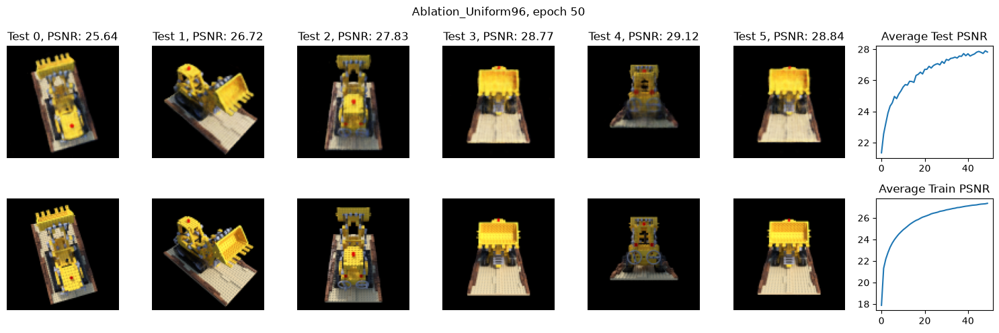

[Ablation_Uniform96] epoch  51/100 | train PSNR  27.37 | test PSNR  27.92 |  25.8 s


[Ablation_Uniform96] epoch  52/100 | train PSNR  27.38 | test PSNR  27.98 |  25.8 s


[Ablation_Uniform96] epoch  53/100 | train PSNR  27.42 | test PSNR  27.80 |  25.8 s


[Ablation_Uniform96] epoch  54/100 | train PSNR  27.42 | test PSNR  27.82 |  25.8 s


[Ablation_Uniform96] epoch  55/100 | train PSNR  27.45 | test PSNR  27.96 |  25.8 s


[Ablation_Uniform96] epoch  56/100 | train PSNR  27.47 | test PSNR  28.13 |  25.8 s


[Ablation_Uniform96] epoch  57/100 | train PSNR  27.50 | test PSNR  28.01 |  25.8 s


[Ablation_Uniform96] epoch  58/100 | train PSNR  27.50 | test PSNR  28.06 |  25.8 s


[Ablation_Uniform96] epoch  59/100 | train PSNR  27.53 | test PSNR  27.97 |  25.8 s


[Ablation_Uniform96] epoch  60/100 | train PSNR  27.54 | test PSNR  28.12 |  25.8 s


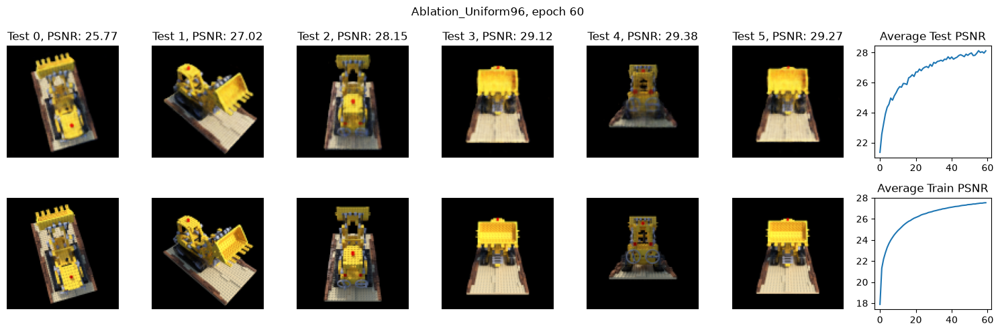

[Ablation_Uniform96] epoch  61/100 | train PSNR  27.56 | test PSNR  28.10 |  25.8 s


[Ablation_Uniform96] epoch  62/100 | train PSNR  27.56 | test PSNR  28.19 |  25.8 s


[Ablation_Uniform96] epoch  63/100 | train PSNR  27.59 | test PSNR  28.02 |  25.8 s


[Ablation_Uniform96] epoch  64/100 | train PSNR  27.61 | test PSNR  28.06 |  25.8 s


[Ablation_Uniform96] epoch  65/100 | train PSNR  27.59 | test PSNR  28.19 |  25.8 s


[Ablation_Uniform96] epoch  66/100 | train PSNR  27.63 | test PSNR  28.17 |  25.8 s


[Ablation_Uniform96] epoch  67/100 | train PSNR  27.64 | test PSNR  28.25 |  25.8 s


[Ablation_Uniform96] epoch  68/100 | train PSNR  27.65 | test PSNR  28.21 |  25.8 s


[Ablation_Uniform96] epoch  69/100 | train PSNR  27.66 | test PSNR  28.12 |  25.8 s


[Ablation_Uniform96] epoch  70/100 | train PSNR  27.69 | test PSNR  28.25 |  25.8 s


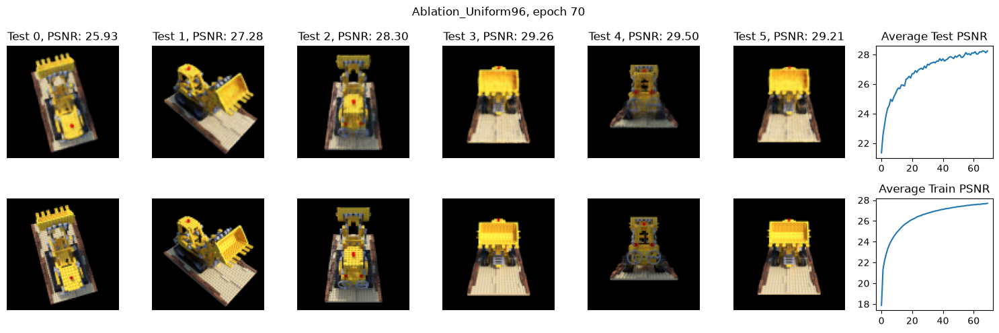

[Ablation_Uniform96] epoch  71/100 | train PSNR  27.70 | test PSNR  28.28 |  25.8 s


[Ablation_Uniform96] epoch  72/100 | train PSNR  27.71 | test PSNR  28.20 |  25.8 s


[Ablation_Uniform96] epoch  73/100 | train PSNR  27.73 | test PSNR  28.15 |  25.8 s


[Ablation_Uniform96] epoch  74/100 | train PSNR  27.73 | test PSNR  28.28 |  25.8 s


[Ablation_Uniform96] epoch  75/100 | train PSNR  27.74 | test PSNR  28.34 |  25.8 s


[Ablation_Uniform96] epoch  76/100 | train PSNR  27.75 | test PSNR  28.23 |  25.8 s


[Ablation_Uniform96] epoch  77/100 | train PSNR  27.75 | test PSNR  28.28 |  25.8 s


[Ablation_Uniform96] epoch  78/100 | train PSNR  27.77 | test PSNR  28.18 |  25.8 s


[Ablation_Uniform96] epoch  79/100 | train PSNR  27.79 | test PSNR  28.36 |  25.8 s


[Ablation_Uniform96] epoch  80/100 | train PSNR  27.79 | test PSNR  28.22 |  25.8 s


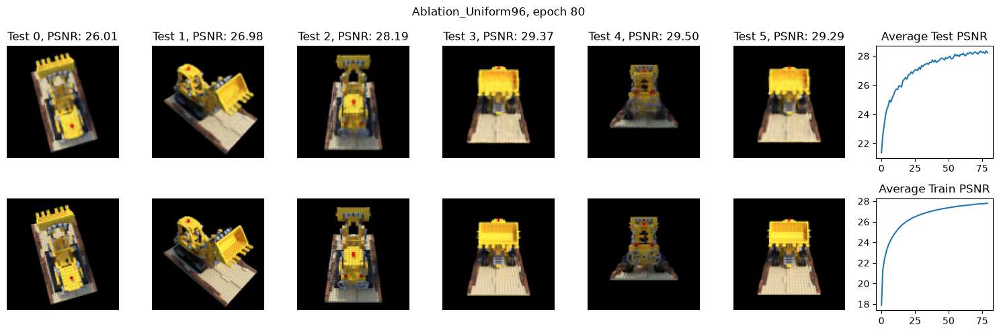

[Ablation_Uniform96] epoch  81/100 | train PSNR  27.80 | test PSNR  28.25 |  25.8 s


[Ablation_Uniform96] epoch  82/100 | train PSNR  27.81 | test PSNR  28.35 |  25.8 s


[Ablation_Uniform96] epoch  83/100 | train PSNR  27.82 | test PSNR  28.36 |  25.8 s


[Ablation_Uniform96] epoch  84/100 | train PSNR  27.83 | test PSNR  28.35 |  25.8 s


[Ablation_Uniform96] epoch  85/100 | train PSNR  27.83 | test PSNR  28.33 |  25.8 s


[Ablation_Uniform96] epoch  86/100 | train PSNR  27.85 | test PSNR  28.24 |  25.8 s


[Ablation_Uniform96] epoch  87/100 | train PSNR  27.85 | test PSNR  28.33 |  25.8 s


[Ablation_Uniform96] epoch  88/100 | train PSNR  27.84 | test PSNR  28.27 |  25.8 s


[Ablation_Uniform96] epoch  89/100 | train PSNR  27.87 | test PSNR  28.39 |  25.8 s


[Ablation_Uniform96] epoch  90/100 | train PSNR  27.86 | test PSNR  28.31 |  25.8 s


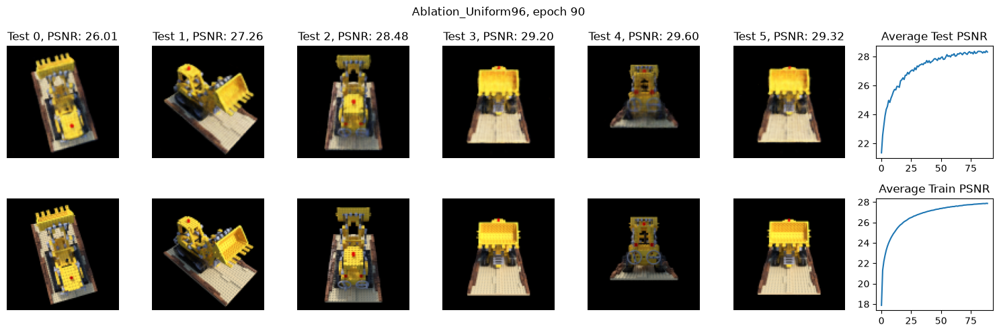

[Ablation_Uniform96] epoch  91/100 | train PSNR  27.89 | test PSNR  28.42 |  25.8 s


[Ablation_Uniform96] epoch  92/100 | train PSNR  27.89 | test PSNR  28.44 |  25.8 s


[Ablation_Uniform96] epoch  93/100 | train PSNR  27.90 | test PSNR  28.35 |  25.8 s


[Ablation_Uniform96] epoch  94/100 | train PSNR  27.89 | test PSNR  28.39 |  25.8 s


[Ablation_Uniform96] epoch  95/100 | train PSNR  27.92 | test PSNR  28.44 |  25.8 s


[Ablation_Uniform96] epoch  96/100 | train PSNR  27.93 | test PSNR  28.42 |  25.8 s


[Ablation_Uniform96] epoch  97/100 | train PSNR  27.93 | test PSNR  28.39 |  25.8 s


[Ablation_Uniform96] epoch  98/100 | train PSNR  27.93 | test PSNR  28.34 |  25.8 s


[Ablation_Uniform96] epoch  99/100 | train PSNR  27.92 | test PSNR  28.35 |  25.8 s


[Ablation_Uniform96] epoch 100/100 | train PSNR  27.94 | test PSNR  28.34 |  25.8 s


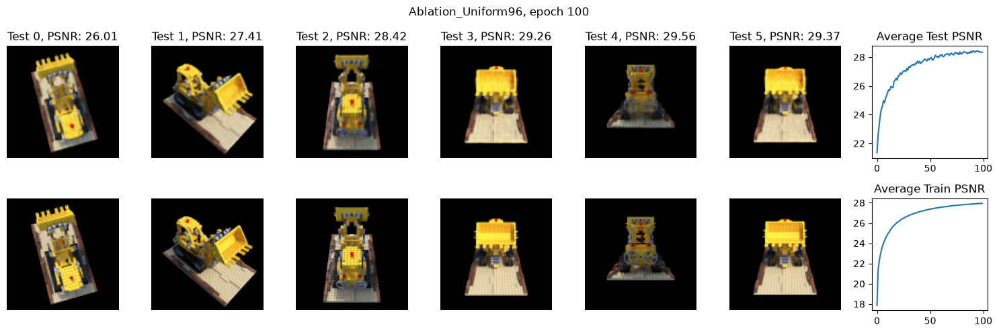

Ablation A final test PSNR 26.41 dB | Ablation B final test PSNR 28.34 dB


In [19]:
# Ablation A: hierarchical sampling, matte colour (same networks, direction input zeroed)
abl_coarse = NeRF(filter_size=128, L_embed=6, view_dependent=False).to(device)
abl_fine = NeRF(filter_size=128, L_embed=6, view_dependent=False).to(device)
history_a = train("Ablation_NoViewDirs", [abl_coarse, abl_fine],
                  lambda o, d: list(render_rays(abl_coarse, abl_fine, o, d, NEAR, FAR, N_C, N_F, rand=True)),
                  lambda o, d: render_rays(abl_coarse, abl_fine, o, d, NEAR, FAR, N_C, N_F, rand=False)[1],
                  N_EPOCHS)
torch.save({"coarse": abl_coarse.state_dict(), "fine": abl_fine.state_dict(),
            "config": {"view_dependent": False, "N_c": N_C, "N_f": N_F, "epochs": N_EPOCHS, "seed": SEED}},
           "ablation_no_viewdirs.pth")
save_history("Ablation_NoViewDirs", history_a)

# Ablation B: view-dependent colour, one network, N_C + N_F uniform samples (no coarse pass)
abl_uniform = NeRF(filter_size=128, L_embed=6).to(device)
history_b = train("Ablation_Uniform96", [abl_uniform],
                  lambda o, d: [render_rays_uniform(abl_uniform, o, d, NEAR, FAR, N_C + N_F, rand=True)],
                  lambda o, d: render_rays_uniform(abl_uniform, o, d, NEAR, FAR, N_C + N_F, rand=False),
                  N_EPOCHS)
torch.save({"model": abl_uniform.state_dict(),
            "config": {"view_dependent": True, "num_samples": N_C + N_F, "epochs": N_EPOCHS, "seed": SEED}},
           "ablation_uniform96.pth")
save_history("Ablation_Uniform96", history_b)
print(f"Ablation A final test PSNR {history_a['test_psnr'][-1]:.2f} dB | "
      f"Ablation B final test PSNR {history_b['test_psnr'][-1]:.2f} dB")